___
___

# **Impacto de la electrificación del transporte en las emisiones de GEI en Europa**

### Librerias necesarias 🧩

Este script requiere las siguientes librerías y módulo para funcionar correctamente:
- `pathlib` (módulo de `Python`, no necesita instalación)
- `pandas`
- `matplotlib`
- `seaborn`
- `plotly`

Si no las tienes instaladas, puedes hacerlo ejecutando el siguiente comando:

```bash
pip install pandas matplotlib seaborn plotly
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter
from pathlib import Path

### Configuración del tema visual para las gráficas 🎨

Se establece la configuración de visualización de __Seaborn__ para usar un contexto de presentación (`context='poster'`, ideal para gráficos grandes), se aplica un estilo minimalista oscuro sin cuadrícula (`style='dark'`), y se configura la paleta de colores a un esquema brillante (`palette='bright'`).

In [2]:
sns.set_theme(context='poster', style='dark', palette='bright')

___
## 🌍 **Gases de efecto invernadero**

### 📑 **Dataframe utilizado**
__Nombre__: _Greenhouse gas emissions by source sector_ (`env_air_gge`)  
__Fuente oficial__: [Agencia Europea de Medio Ambiente (EEA)](https://www.eea.europa.eu/en)  
__Acceso a los datos__: [Eurostat - Data Browser](https://ec.europa.eu/eurostat/databrowser/view/env_air_gge__custom_17266610/default/table?lang=en)

#### Descripción general del dataframe

- Frecuencia temporal: Anual (A)
- Unidad de medida: Millones de toneladas (MIO_T)
- Cobertura geográfica: Países de la Unión Europea
- Contaminantes incluidos:
    - Dióxido de carbono (CO2)
    - Óxido nitroso (N2O)
    - Metano (CH4)
    - Hidrofluorocarbonos (HFC)
    - Perfluorocarbonos (PFC)
    - Hexafluoruro de azufre (SF6)
    - Trifluoruro de nitrógeno (NF3)
- Clasificación sectorial: Emisiones agrupadas por sector fuente (transporte, industria, agricultura, etc.)

#### Nota adicional
Este conjunto de datos es ampliamente utilizado para el análisis de emisiones de gases de efecto invernadero en Europa. La clasificación y codificación siguen los estándares de Eurostat para facilitar la interoperabilidad con otras fuentes ambientales.

#### Carga de datos 🧭

En este paso se carga el archivo Excel que contiene los datos de emisiones de gases de efecto invernadero. El archivo debe estar ubicado en la carpeta `data/raw`.

In [3]:
# Buscar la carpeta 'data/raw' hacia arriba desde el notebook actual
base_path = Path.cwd()
while not (base_path / "data" / "raw").exists() and base_path.parent != base_path:
    base_path = base_path.parent

file_path = base_path / "data" / "raw" / "env_air_gge__custom_15714287_page_spreadsheet.xlsx"

df_greenhouse_gases = pd.read_excel(file_path, sheet_name='Data')
df_greenhouse_gases.head()

,GEO (Codes),GEO (Labels),TIME,TOTXMEMO,CRF1,CRF1A1,CRF1A2,CRF1A3,CRF1A3A,CRF1A3B,...,CRF1C,CRF1D1,CRF1D2,CRF1D3,CRF2,CRF3,CRF4,CRF5,CRF6,CRF_INDCO2
0,EU27_2020,European Union - 27 countries (from 2020),1990,4649770.44,3741199.78,1442246.90,721407.71,672182.73,11348.39,620116.66,...,NaN,156807.56,0.67,210250.14,450551.75,483165.78,-217472.28,184583.12,NaN,7742.29
1,EU27_2020,European Union - 27 countries (from 2020),1991,4444605.53,3691909.94,1409716.14,678277.58,680852.30,11336.73,629307.69,...,NaN,154118.70,1.14,223185.68,419169.34,455098.05,-316931.49,187794.00,NaN,7565.69
2,EU27_2020,European Union - 27 countries (from 2020),1992,4320714.82,3572830.87,1363222.85,639581.99,702853.18,11603.13,651585.34,...,NaN,159276.13,0.98,221350.93,406060.96,434383.75,-289473.78,189545.26,NaN,7367.76
3,EU27_2020,European Union - 27 countries (from 2020),1993,4226725.66,3514512.39,1311751.92,619343.91,706231.71,11418.36,657461.06,...,NaN,162767.81,0.94,240420.93,396000.85,422919.61,-303318.69,189371.20,NaN,7240.31
4,EU27_2020,European Union - 27 countries (from 2020),1994,4214004.13,3475615.04,1318365.00,617414.61,711670.29,11791.19,663285.15,...,NaN,165812.30,0.86,239770.77,419550.75,417601.43,-294016.11,188156.07,NaN,7096.94


### 🔎 **Diagnóstico inicial de los datos (EDA)**

En esta sección se realiza una inspección inicial del dataframe crudo para comprender su estructura, calidad y contenido antes de aplicar transformaciones.

Comprobaré:
- Tipos de datos
- Presencia de valores nulos.
- Duplicados.
- Estadísticas descriptivas básicas.

#### Información general del dataframe


Países disponibles:
['European Union - 27 countries (from 2020)']

Tipos de datos y resumen general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GEO (Codes)   33 non-null     object 
 1   GEO (Labels)  33 non-null     object 
 2   TIME          33 non-null     int64  
 3   TOTXMEMO      33 non-null     float64
 4   CRF1          33 non-null     float64
 5   CRF1A1        33 non-null     float64
 6   CRF1A2        33 non-null     float64
 7   CRF1A3        33 non-null     float64
 8   CRF1A3A       33 non-null     float64
 9   CRF1A3B       33 non-null     float64
 10  CRF1A3B1      33 non-null     float64
 11  CRF1A3B2      33 non-null     float64
 12  CRF1A3B3      33 non-null     float64
 13  CRF1A3B4      33 non-null     float64
 14  CRF1A3B5      33 non-null     float64
 15  CRF1A3C       33 non-null     float64
 16  CRF1A3D       33

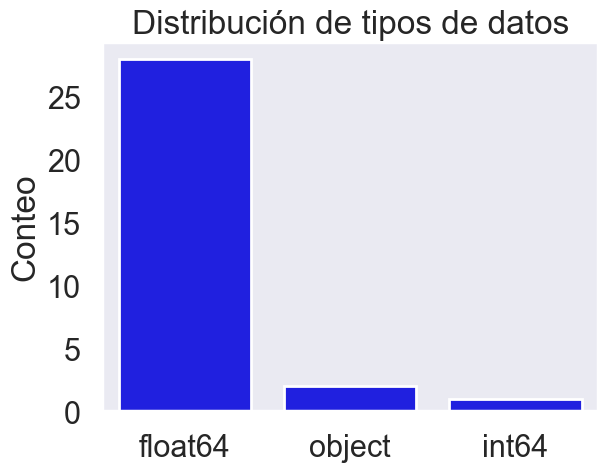

In [4]:
print('\nPaíses disponibles:')
print(df_greenhouse_gases['GEO (Labels)'].unique())

print('\nTipos de datos y resumen general:')
df_greenhouse_gases.info()

dtype_counts = df_greenhouse_gases.dtypes.value_counts().reset_index()
dtype_counts.columns = ['dtype', 'count']

sns.barplot(data=dtype_counts, x='dtype', y='count', color='blue')
plt.title('Distribución de tipos de datos')
plt.ylabel('Conteo')
plt.xlabel(None)
plt.show()

#### Filas duplicadas y nulos por columna

Total de filas duplicadas:
0

Valores nulos por columna:
CRF1C           33
CRF6            33
GEO (Codes)      0
TOTXMEMO         0
CRF1             0
GEO (Labels)     0
TIME             0
CRF1A3           0
CRF1A3A          0
CRF1A3B          0
CRF1A3B1         0
CRF1A3B2         0
CRF1A3B3         0
CRF1A1           0
CRF1A2           0
CRF1A3B5         0
CRF1A3B4         0
CRF1A3E          0
CRF1A3C          0
CRF1A4           0
CRF1A5           0
CRF1B            0
CRF1A3D          0
CRF1D1           0
CRF1D2           0
CRF2             0
CRF1D3           0
CRF3             0
CRF4             0
CRF5             0
CRF_INDCO2       0
dtype: int64


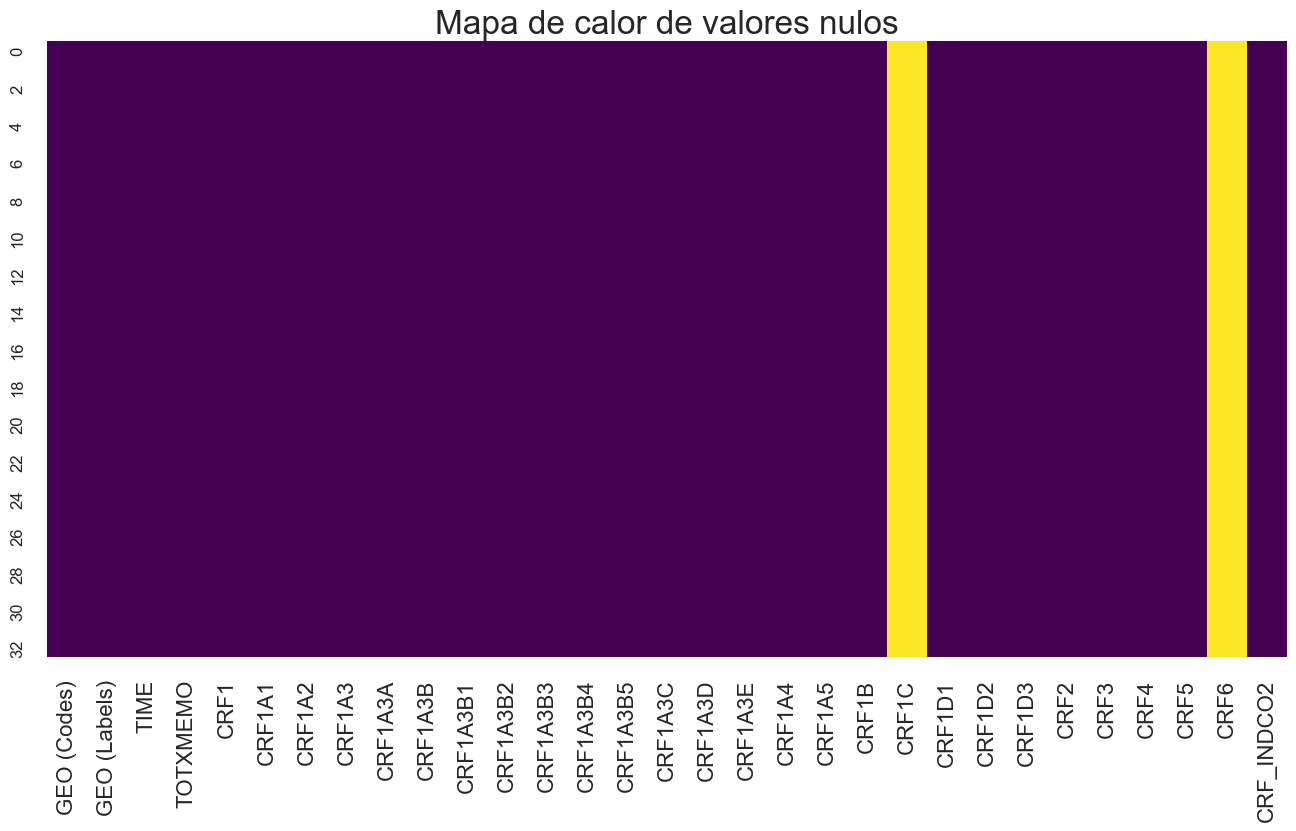

In [5]:
print('Total de filas duplicadas:')
print(df_greenhouse_gases.duplicated().sum())

print('\nValores nulos por columna:')
print(df_greenhouse_gases.isnull().sum().sort_values(ascending=False))

plt.figure(figsize=(16, 8))
sns.heatmap(df_greenhouse_gases.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.show()

#### Estadísticas descriptivas básicas

In [6]:
print('Estadísticas básicas (variables numéricas):')
df_greenhouse_gases.describe().round(1)

Estadísticas básicas (variables numéricas):


,TIME,TOTXMEMO,CRF1,CRF1A1,CRF1A2,CRF1A3,CRF1A3A,CRF1A3B,CRF1A3B1,CRF1A3B2,...,CRF1C,CRF1D1,CRF1D2,CRF1D3,CRF2,CRF3,CRF4,CRF5,CRF6,CRF_INDCO2
count,33.0,33.0,33.0,33.0,33.0,33.0,33.0,33.0,33.0,33.0,...,0.0,33.0,33.0,33.0,33.0,33.0,33.0,33.0,0.0,33.0
mean,2006.0,3914869.2,3286780.3,1232304.8,525402.7,786639.4,14154.6,740249.8,452743.1,81831.7,...,NaN,220949.3,14.9,395783.1,386409.9,397894.2,-312929.8,151253.1,NaN,5461.6
std,9.7,418023.3,347817.4,180046.7,93302.0,52649.2,2252.6,53010.0,29358.1,10289.7,...,NaN,38812.8,49.4,133193.0,44458.0,25668.9,42914.2,29245.5,NaN,1299.2
min,1990.0,3052044.4,2489952.9,778460.5,392586.0,672182.7,7874.1,620116.7,389167.2,59329.4,...,NaN,154118.7,0.7,210250.1,291844.5,365719.0,-361543.7,109707.0,NaN,3626.9
25%,1998.0,3553809.4,2970429.1,1113712.8,431409.9,756319.0,13079.2,705694.4,435006.7,78481.9,...,NaN,190717.4,1.4,276138.0,347914.7,379870.1,-348225.0,120599.7,NaN,4155.0
50%,2006.0,4141954.0,3470439.2,1311751.9,549172.6,802210.5,14598.8,755024.5,461509.0,84733.8,...,NaN,233092.5,1.7,377503.5,402445.4,386815.4,-324538.6,151962.8,NaN,5642.2
75%,2014.0,4214004.1,3537005.0,1352480.6,595841.5,823107.3,16055.9,778113.5,479018.6,87710.6,...,NaN,250224.1,2.2,528486.9,420550.3,414337.1,-294016.1,179602.6,NaN,6585.9
max,2022.0,4649770.4,3741199.8,1442246.9,721407.7,863477.6,16907.8,813156.2,487229.1,97239.5,...,NaN,278190.0,263.2,604470.2,450551.8,483165.8,-217472.3,189545.3,NaN,7742.3


### 🛠️ **Preparación y transformación de datos**

En los siguientes bloques se realizarán tareas de limpieza, normalización y reestructuración del dataframe para que esté listo para el análisis. Estas transformaciones tienen como propósito simplificar el dataframe, facilitar el análisis comparativo por tipo de energía, y garantizar que los datos reflejen únicamente a la Unión Europea (27 países) de forma consolidada y comprensible.

1. __Convertir los valores de miles a millones__  
   Se convertiran los valores a millones de toneladas para facilitar la interpretabilidad de las unidades, pasar de por ejemplo de _28 mil miles de toneladas_ a _28 millones de toneladas_.

2. __Eliminar columnas vacias__  
   Se eliminarán estas columnas que están completamente vacías ya que no aportan información útil al análisis. Como `CRF1C` (_Transporte y almacenamiento de CO₂_) y `CRF6` (_Otros sectores_)

3. __Agrupación de categorías principales a traves de sus subcategorías__  
   `CRF1A` (_Combustión por sector_): Suma de las subcategorías de combustión (`CRF1A1` a `CRF1A5`) para analizar el total de emisiones por este tipo de fuente.
   `CRF1D` (_Ítems informativos_): Se crea una nueva columna combinando las subcategorías `CRF1D1`, `CRF1D2` y `CRF1D3`. Luego se eliminan estas columnas originales para evitar redundancia.

4. __Crear nuevas columnas que incluyan los ítems informativos__  
   `CRF1NMEMO` (_Energía con ítems informativos_): Suma de `CRF1` (energía) y `CRF1D` (ítems informativos), para obtener una visión más completa de las emisiones del sector energético.
   `TOTNMEMO` (_Total con ítems informativos_): Combinación de `TOTXMEMO` y `CRF1D`, integrando así componentes que suelen excluirse del total base.

5. __Renombrado de columnas__  
   Las columnas se renombran a nombres más descriptivos y amigables para el análisis.

#### Convertir los valores de miles de toneladas a millones de toneladas

In [ ]:
#Columnas a excluir de la converción.
exclude_cols = ['GEO (Codes)', 'GEO (Labels)', 'TIME']

# Detectar columnas de tipo float (y que no estén en la lista de exclusión)
cols_to_convert = [
    col for col in df_greenhouse_gases.select_dtypes(include='float').columns
    if col not in exclude_cols
]
# Convertir valores de miles a millones
df_greenhouse_gases[cols_to_convert] = df_greenhouse_gases[cols_to_convert]/1000
df_greenhouse_gases[cols_to_convert] = df_greenhouse_gases[cols_to_convert].round(2)

,GEO (Codes),GEO (Labels),TIME,TOTXMEMO,CRF1,CRF1A1,CRF1A2,CRF1A3,CRF1A3A,CRF1A3B,...,CRF1C,CRF1D1,CRF1D2,CRF1D3,CRF2,CRF3,CRF4,CRF5,CRF6,CRF_INDCO2
0,EU27_2020,European Union - 27 countries (from 2020),1990,4649.77,3741.20,1442.25,721.41,672.18,11.35,620.12,...,NaN,156.81,0.0,210.25,450.55,483.17,-217.47,184.58,NaN,7.74
1,EU27_2020,European Union - 27 countries (from 2020),1991,4444.61,3691.91,1409.72,678.28,680.85,11.34,629.31,...,NaN,154.12,0.0,223.19,419.17,455.10,-316.93,187.79,NaN,7.57
2,EU27_2020,European Union - 27 countries (from 2020),1992,4320.71,3572.83,1363.22,639.58,702.85,11.60,651.59,...,NaN,159.28,0.0,221.35,406.06,434.38,-289.47,189.55,NaN,7.37
3,EU27_2020,European Union - 27 countries (from 2020),1993,4226.73,3514.51,1311.75,619.34,706.23,11.42,657.46,...,NaN,162.77,0.0,240.42,396.00,422.92,-303.32,189.37,NaN,7.24
4,EU27_2020,European Union - 27 countries (from 2020),1994,4214.00,3475.62,1318.36,617.41,711.67,11.79,663.29,...,NaN,165.81,0.0,239.77,419.55,417.60,-294.02,188.16,NaN,7.10


#### Eliminar columnas sin valor informativo

In [8]:
# Eliminar las columnas 'CRF1C' y 'CRF6' porque contienen solo valores nulos
df_greenhouse_gases.drop(labels=['CRF1C', 'CRF6'], axis=1, inplace=True)

# Eliminar columna de etiquetas geográficas (GEO (Labels))
df_greenhouse_gases = df_greenhouse_gases.drop(labels=['GEO (Labels)'], axis=1)

#### Crear nuevas columnas a partir de subcategorías

In [9]:
# Crear 'CRF1D' como suma de subcategorías informativas
df_greenhouse_gases['CRF1D'] = df_greenhouse_gases[['CRF1D1', 'CRF1D2', 'CRF1D3']].sum(axis=1).round(2)
df_greenhouse_gases.insert(22, 'CRF1D', df_greenhouse_gases.pop('CRF1D'))

# Eliminar subcolumnas originales de ítems informativos
df_greenhouse_gases.drop(labels=['CRF1D1', 'CRF1D2', 'CRF1D3'], axis=1, inplace=True)

# Crear 'CRF1NMEMO': Energía incluyendo ítems informativos
df_greenhouse_gases['CRF1NMEMO'] = df_greenhouse_gases[['CRF1', 'CRF1D']].sum(axis=1).round(2)
df_greenhouse_gases.insert(4, 'CRF1NMEMO', df_greenhouse_gases.pop('CRF1NMEMO'))

# Crear 'TOTNMEMO': Total incluyendo ítems informativos
df_greenhouse_gases['TOTNMEMO'] = df_greenhouse_gases[['TOTXMEMO', 'CRF1D']].sum(axis=1).round(2)
df_greenhouse_gases.insert(3, 'TOTNMEMO', df_greenhouse_gases.pop('TOTNMEMO'))

# Crear 'CRF1A': Combustión por sector (suma de subcategorías CRF1A1 a CRF1A5)
df_greenhouse_gases['CRF1A'] = df_greenhouse_gases[['CRF1A1', 'CRF1A2', 'CRF1A3', 'CRF1A4', 'CRF1A5']].sum(axis=1).round(2)
df_greenhouse_gases.insert(7, 'CRF1A', df_greenhouse_gases.pop('CRF1A'))

#### Renombrar y limpiar nombres de columnas

In [10]:
# Renombrar columnas a nombres más descriptivos
df_greenhouse_gases = df_greenhouse_gases.rename(columns={
    'GEO_(Codes)':'Geocódigos',
    'TIME':'Años',
    'TOTNMEMO':'Total (con informativos)',
    'TOTXMEMO':'Total (sin informativos)', 
    'CRF1NMEMO':'Energía (con informativos)',
    'CRF1':'Energía',
    'CRF1A':'Combustión por sector',
    'CRF1A1':'Combustión en las industrias energéticas',
    'CRF1A2':'Combustión en manufactura y construcción',
    'CRF1A3':'Combustión en el transporte',
    'CRF1A3A':'Combustión en la aviación nacional',
    'CRF1A3B':'Combustión en el transporte por carretera',
    'CRF1A3B1':'Combustión en automóviles',
    'CRF1A3B2':'Combustión en camiones ligeros',
    'CRF1A3B3':'Combustión en camiones pesados ​​y autobuses',
    'CRF1A3B4':'Combustión en motocicletas',
    'CRF1A3B5':'Combustión en otros transportes por carretera',
    'CRF1A3C':'Combustión en ferrocarriles',
    'CRF1A3D':'Combustión en la navegación interior',
    'CRF1A3E':'Combustión en otros transportes',
    'CRF1A4':'Otros sectores de combustión',
    'CRF1A5':'Otros sectores de combustión n.c.p.',
    'CRF1B':'Combustibles  emisiones fugitivas',
    'CRF1D':'Ítems informativos',
    'CRF2':'Procesos y productos industriales',
    'CRF3':'Agricultura',
    'CRF4':'Uso del suelo y silvicultura (UTCUTS)',
    'CRF5':'Gestión de residuos',
    'CRF_INDCO2':'CO2 indirecto'})

# Estandarizar nombres de columnas: reemplazar espacios por guiones bajos
df_greenhouse_gases.columns = df_greenhouse_gases.columns.str.strip().str.replace(' ', '_')

# Vista previa del dataframe
df_greenhouse_gases.head()

,GEO_(Codes),Años,Total_(sin_informativos),Total_(con_informativos),Energía,Energía_(con_informativos),Combustión_en_las_industrias_energéticas,Combustión_por_sector,Combustión_en_manufactura_y_construcción,Combustión_en_el_transporte,...,Combustión_en_otros_transportes,Otros_sectores_de_combustión,Otros_sectores_de_combustión_n.c.p.,Combustibles__emisiones_fugitivas,Ítems_informativos,Procesos_y_productos_industriales,Agricultura,Uso_del_suelo_y_silvicultura_(UTCUTS),Gestión_de_residuos,CO2_indirecto
0,EU27_2020,1990,4649.77,5016.83,3741.20,4108.26,1442.25,3572.19,721.41,672.18,...,6.14,713.92,22.43,169.01,367.06,450.55,483.17,-217.47,184.58,7.74
1,EU27_2020,1991,4444.61,4821.92,3691.91,4069.22,1409.72,3536.14,678.28,680.85,...,6.32,748.54,18.75,155.78,377.31,419.17,455.10,-316.93,187.79,7.57
2,EU27_2020,1992,4320.71,4701.34,3572.83,3953.46,1363.22,3421.81,639.58,702.85,...,6.13,701.09,15.07,151.01,380.63,406.06,434.38,-289.47,189.55,7.37
3,EU27_2020,1993,4226.73,4629.92,3514.51,3917.70,1311.75,3364.36,619.34,706.23,...,5.49,714.65,12.39,150.14,403.19,396.00,422.92,-303.32,189.37,7.24
4,EU27_2020,1994,4214.00,4619.58,3475.62,3881.20,1318.36,3329.63,617.41,711.67,...,5.03,670.79,11.40,145.97,405.58,419.55,417.60,-294.02,188.16,7.10


#### Exportación del dataframe limpio 💾

El dataframe transformado se guarda como archivo `.csv` en la carpeta `data/processed`. Esto permite reutilizar los datos ya procesados sin volver a ejecutar todos los pasos anteriores.

In [41]:
# Buscar la carpeta 'data/processed' desde el notebook actual
base_path = Path.cwd()
while not (base_path / "data" / "processed").exists() and base_path.parent != base_path:
    base_path = base_path.parent

output_dir = base_path / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "df_greenhouse_gases.csv"

df_greenhouse_gases.to_csv(output_path, index=False, encoding='utf-8')

### 📈 **Análisis visual e interpretación.**

#### __¿Cómo han evolucionado las emisiones de gases de efecto invernadero (GEI) a lo largo del tiempo?__

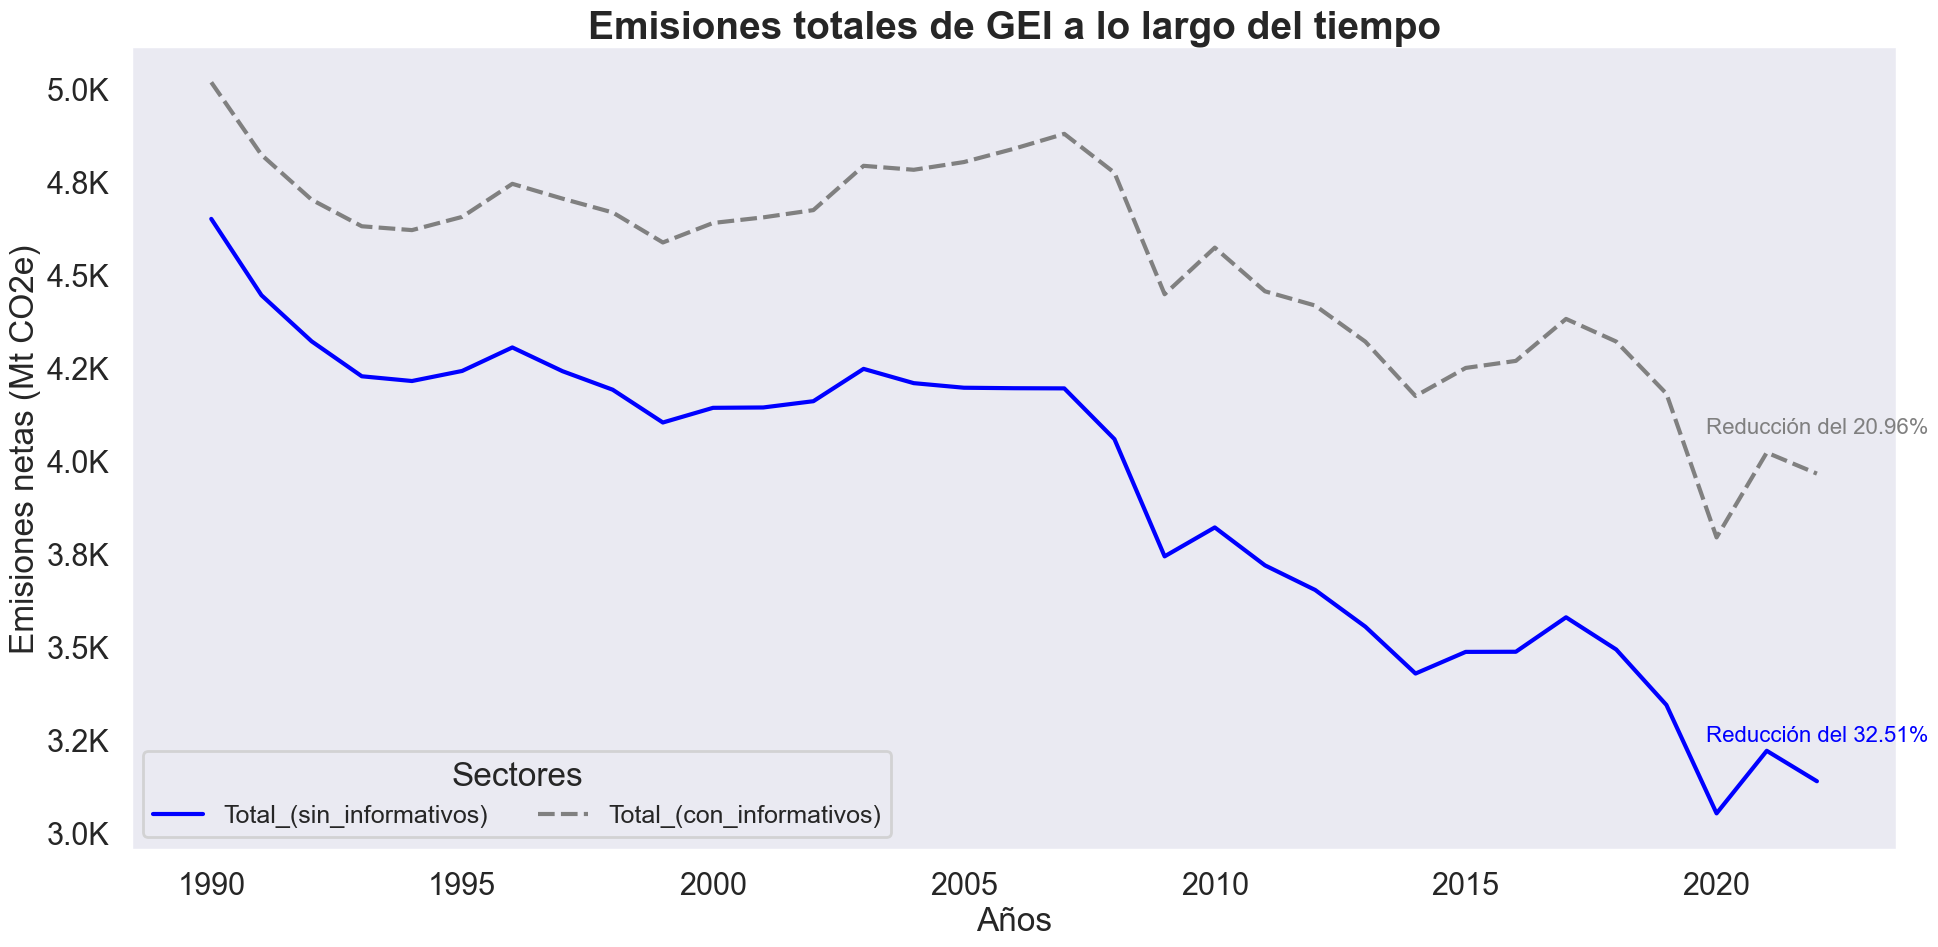

In [47]:
# Cálculo de la evolución de las emisiones de GEI.
emisiones_1990 = df_greenhouse_gases[df_greenhouse_gases['Años'] == 1990]
emisiones_2022 = df_greenhouse_gases[df_greenhouse_gases['Años'] == 2022]

abs_red_con = emisiones_1990['Total_(con_informativos)'].values[0] - emisiones_2022['Total_(con_informativos)'].values[0]
pct_red_con = abs_red_con / emisiones_1990['Total_(con_informativos)'].values[0] * 100

abs_red_sin = emisiones_1990['Total_(sin_informativos)'].values[0] - emisiones_2022['Total_(sin_informativos)'].values[0]
pct_red_sin = abs_red_sin / emisiones_1990['Total_(sin_informativos)'].values[0] * 100

df_ghe_melt = df_greenhouse_gases.melt(
    id_vars='Años',
    value_vars=[
        'Total_(sin_informativos)',
        'Total_(con_informativos)'],
    var_name='Sectores',
    value_name='Emisiones')

# Gráfico de la evolución de las emisiones de GEI.
plt.figure(figsize=(20, 10), tight_layout=True)
ax = sns.lineplot(
    data=df_ghe_melt,
    x='Años',
    y='Emisiones',
    hue='Sectores',
    style='Sectores',
    palette=['blue', 'gray'])
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e3:.1f}K'))
plt.legend(
    title='Sectores', loc='lower left',
    ncol=2, fontsize=18)
plt.title(
    'Emisiones totales de GEI a lo largo del tiempo',
    fontdict={'fontsize':28, 'fontweight':'bold'})
plt.ylabel('Emisiones netas (Mt CO2e)')
# Obtener límites del eje y
ymin, ymax = ax.get_ylim()
offset = (ymax - ymin) * 0.05
# 🔵 Texto sobre las emisiones sin informativos
x_text_1 = 2022
y_text_1 = df_ghe_melt.query('Años == @x_text_1 and Sectores == "Total_(sin_informativos)"')['Emisiones'].values[0]
ax.text(
    x_text_1, y_text_1 + offset,
    f'Reducción del {pct_red_sin:.2f}%',
    color='blue', fontsize=16, ha='center')
# ⚫ Texto sobre las emisiones con informativos
x_text_2 = 2022
y_text_2 = df_ghe_melt.query('Años == @x_text_2 and Sectores == "Total_(con_informativos)"')['Emisiones'].values[0]
ax.text(
    x_text_2, y_text_2 + offset,
    f'Reducción del {pct_red_con:.2f}%',
    color='gray', fontsize=16, ha='center')
plt.show()

En la gráfica vemos la evolución de las emisiones netas totales de GEI desde 1990 hasta el año 2022, tanto incluyendo como excluyendo los sectores informativos. Se evidencia una tendencia general a la baja, con una reducción del 32.51% en las emisiones totales (sin informativos), aunque una reducción menor del 20.96% en el caso con informativos.

Podemos apreciar que, a pesar de ciertas fluctuaciones interanuales, se ha tenido un efecto positivo en la disminución de las emisiones. La comparación entre las dos líneas también permite evaluar el impacto de los sectores informativos en la contabilidad total de emisiones.

Así que para responder a la pregunta: ¿Cómo han evolucionado las emisiones de gases de efecto invernadero (GEI) a lo largo del tiempo?, diremos que las emisiones han evolucionado favorablemente hacia los objetivos climáticos de llegar a redicirse en al menos un 55% para el año 2030, respeto a los niveles de 1990.

#### __¿Qué sectores contribuyen más a las emisiones de GEI y cómo ha cambiado su participación a lo largo del tiempo?__

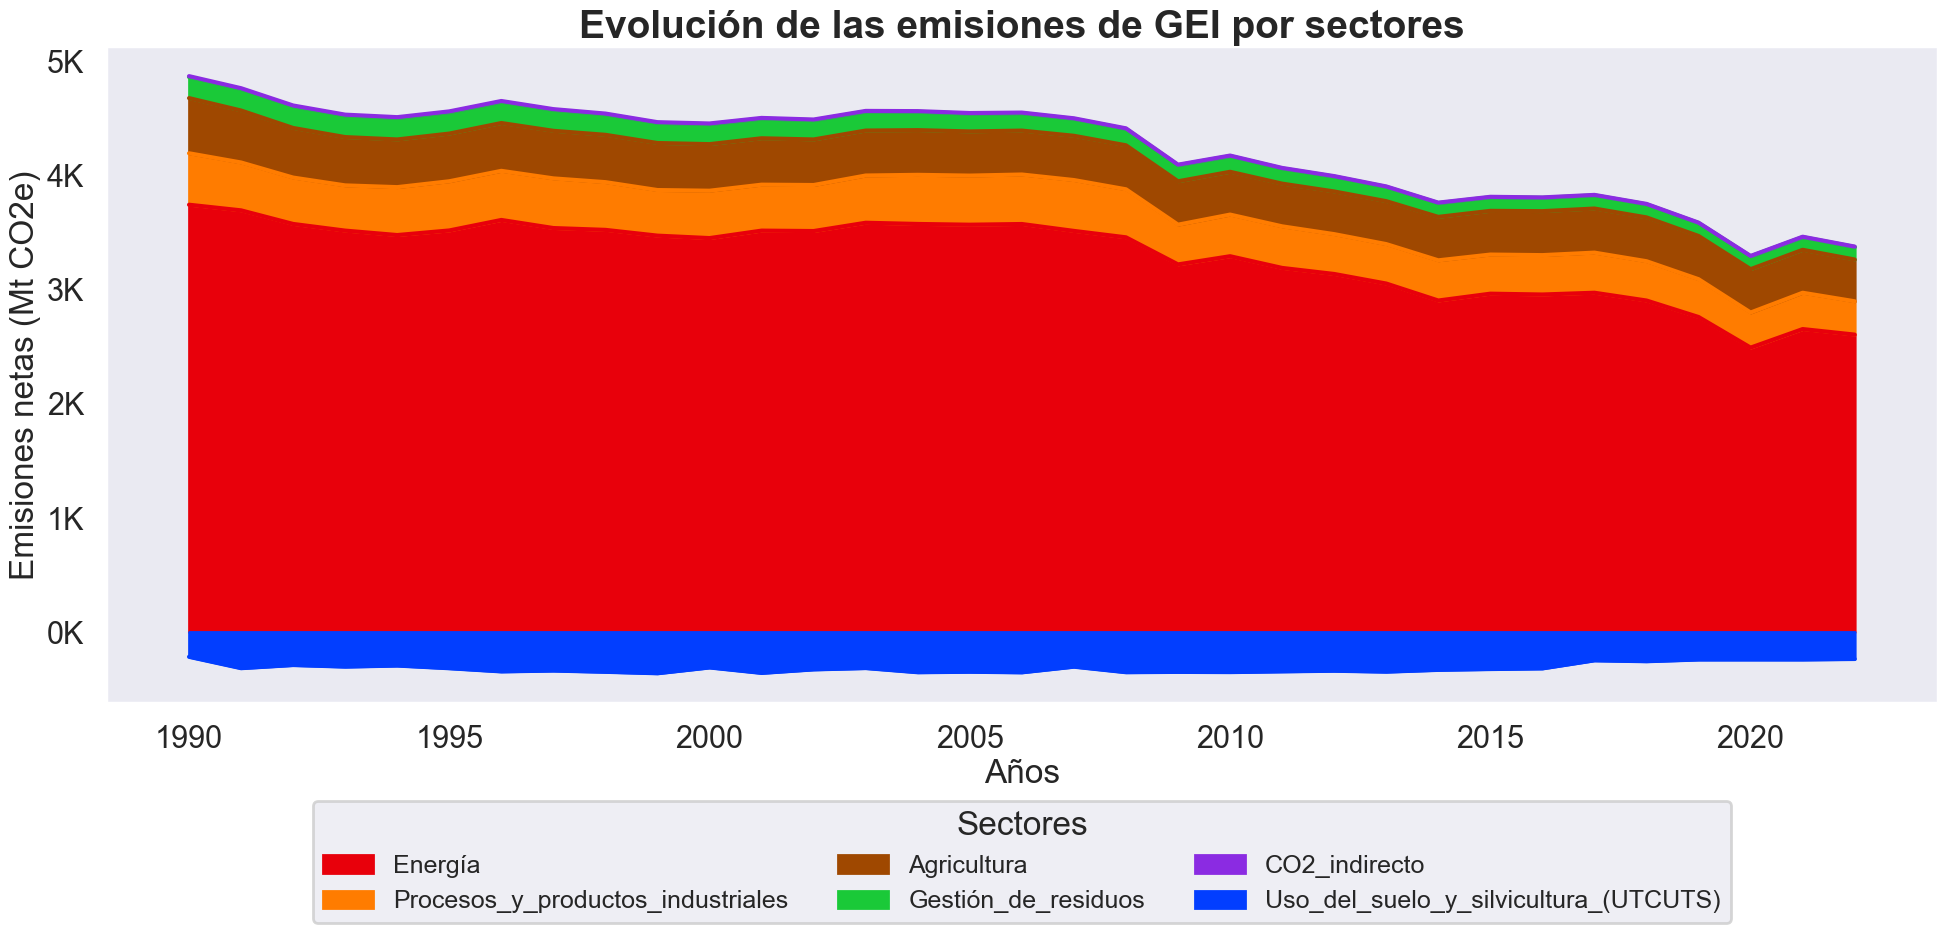

In [13]:
df_greenhouse_gases_by_sectors = df_greenhouse_gases[[
    'Años',
    'Energía',
    'Procesos_y_productos_industriales',
    'Agricultura',
    'Gestión_de_residuos',
    'CO2_indirecto',
    'Uso_del_suelo_y_silvicultura_(UTCUTS)']]
df_greenhouse_gases_by_sectors = df_greenhouse_gases_by_sectors.set_index('Años')

custom_colors = {
    'Energía': '#e8000b',
    'Procesos_y_productos_industriales': '#ff7c00',
    'Agricultura': '#9f4800',
    'Gestión_de_residuos': '#1ac938',
    'CO2_indirecto': '#8b2be2',
    'Uso_del_suelo_y_silvicultura_(UTCUTS)': '#023eff'}

ax = df_greenhouse_gases_by_sectors.plot(
    kind='area',
    stacked=True,
    figsize=(20, 10),
    color=custom_colors)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e3:.0f}K'))
plt.legend(
    title='Sectores', loc='upper center',
    ncol=3, fontsize=18, bbox_to_anchor=(0.5, -0.13))
plt.title(
    'Evolución de las emisiones de GEI por sectores',
    fontdict={'fontsize':28, 'fontweight':'bold'})
plt.ylabel('Emisiones netas (Mt CO2e)')
plt.tight_layout()
plt.show()

Esta gráfica nos permite visualizar cómo se distribuyen las emisiones netas de gases de efecto invernadero (GEI) entre los diferentes sectores a lo largo del tiempo. Se observa claramente que el sector _Energía_ ha sido consistentemente el principal emisor, representando la mayor proporción de las emisiones durante todo el periodo analizado.

Por otro lado, sectores como _Agricultura_, _Procesos y productos industriales_, _Gestión de residuos_y _CO2 indirecto_ mantienen contribuciones relativamente constantes, mientras que el sector de _Uso del suelo y silvicultura (UTCUTS)_ muestra emisiones negativas, indicando que actúa como un sumidero neto de carbono.

En conjunto, gracias a esta visualización identificamos que _Energía_ es el sector clave responsables de la mayor parte de las emisiones y que nuestro sumidero es _Uso del suelo y silvicultura (UTCUTS)_, esto es fundamental para diseñar estrategias efectivas de reducción de GEI y sectorialmente enfocadas.

#### __¿Cómo se distribuyen las emisiones de gases de efecto invernadero dentro del sector Energía en 2022?__

In [14]:
df_2022 = df_greenhouse_gases[df_greenhouse_gases['Años'] == 2022]

# Categorías directas de 'Energía' (nivel 2)
energy_categories = {
    'Combustibles__emisiones_fugitivas': 'Energía',
    'Ítems_informativos': 'Energía'}

# Subcategorías bajo 'Combustión por sector' (nivel 3)
combustion_subcategories = {
    'Combustión_en_el_transporte': 'Combustión por sector',
    'Combustión_en_las_industrias_energéticas': 'Combustión por sector',
    'Combustión_en_manufactura_y_construcción': 'Combustión por sector',
    'Otros_sectores_de_combustión': 'Combustión por sector',
    'Otros_sectores_de_combustión_n.c.p.': 'Combustión por sector'}

# Construcción de registros jerárquicos
data_rows = []

# Nivel 2: Categorías directas de energías
for col, parent in energy_categories.items():
    value = df_2022[col].values[0]
    data_rows.append({
        'Nivel1': parent,
        'Nivel2': col,
        'Nivel3': None,
        'Emisiones': value})

# Nivel 3: Subcategorías de combustión
for col, parent in combustion_subcategories.items():
    value = df_2022[col].values[0]
    data_rows.append({
        'Nivel1': 'Energía',
        'Nivel2': parent,
        'Nivel3': col,
        'Emisiones': value})

# Crear DataFrame
df_plot = pd.DataFrame(data_rows)

# Mapeo de nombres más amigables
rename_map = {
    'Combustión_en_el_transporte': 'Transporte',
    'Combustión_en_las_industrias_energéticas': 'Industrias energéticas',
    'Combustión_en_manufactura_y_construcción': 'Manufactura y construcción',
    'Otros_sectores_de_combustión': 'Otros sectores de combustión',
    'Otros_sectores_de_combustión_n.c.p.': 'Otros sectores n.c.p.',
    'Combustibles__emisiones_fugitivas': 'Emisiones fugitivas',
    'Ítems_informativos': 'Ítems informativos'}
df_plot.replace(rename_map, inplace=True)

fig = px.treemap(
    df_plot,
    path=['Nivel1', 'Nivel2', 'Nivel3'],
    values='Emisiones',
    color='Emisiones',
    color_continuous_scale='Portland',
    title='Distribución jerárquica de emisiones en el sector Energía (2022)')

fig.update_layout(
    width=1600,
    height=900,
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=18, color='black'),
    title=dict(
        font=dict(size=28, color='black', weight=800),
        x=0.5, xanchor='center'))

fig.show()

En el gráfico se muestra que la mayor parte de las emisiones del sector _Energía_ en 2022 provienen de la _combustión por sector_, en particular de las _industrias energéticas_ y del _transporte_. Y fuera de la combustión por sector vemos que  _ítems informativos_ también representan una proporción significativa de las emisiones.

En conjunto, podemos ver dónde se concentran los mayores focos de emisiones dentro del sector energético, con esta base clara se pueden orientar políticas de mitigación. Llevar a cabo una reducción de las emisiones en las _industrias energéticas_ y en el _transporte_ tendría un efecto significativo en la disminución del impacto ambiental del sector _Energía_ en su conjunto.

#### __¿Qué medios de transporte concentran la mayor parte de las emisiones en 2022?__

In [15]:
df_2022 = df_greenhouse_gases[df_greenhouse_gases['Años'] == 2022]

# Categorías directas de 'Transporte' (nivel 2)
transport_categories = {
    'Combustión_en_la_aviación_nacional': 'Transporte',
    'Combustión_en_ferrocarriles': 'Transporte',
    'Combustión_en_la_navegación_interior': 'Transporte',
    'Combustión_en_otros_transportes': 'Transporte'}

# Subcategorías bajo 'Transporte por carretera' (nivel 3)
road_subcategories = {
    'Combustión_en_motocicletas': 'Combustión_en_el_transporte_por_carretera',
    'Combustión_en_otros_transportes_por_carretera': 'Combustión_en_el_transporte_por_carretera',
    'Combustión_en_camiones_ligeros': 'Combustión_en_el_transporte_por_carretera',
    'Combustión_en_camiones_pesados_​​y_autobuses': 'Combustión_en_el_transporte_por_carretera',
    'Combustión_en_automóviles': 'Combustión_en_el_transporte_por_carretera'}

# Construcción de registros jerárquicos
data_rows = []

# Nivel 2: Categorías directas de transporte
for col, parent in transport_categories.items():
    value = df_2022[col].values[0]
    data_rows.append({
        'Nivel1': parent,
        'Nivel2': col,
        'Nivel3': None,
        'Emisiones': value})

# Nivel 3: Subcategorías de carretera
for col, parent in road_subcategories.items():
    value = df_2022[col].values[0]
    data_rows.append({
        'Nivel1': 'Transporte',
        'Nivel2': parent,
        'Nivel3': col,
        'Emisiones': value})

# Crear DataFrame
df_plot = pd.DataFrame(data_rows)

# Mapeo de nombres más amigables
rename_map = {
    'Combustión_en_la_aviación_nacional': 'Aviación nacional',
    'Combustión_en_ferrocarriles': 'Ferrocarriles',
    'Combustión_en_la_navegación_interior': 'Navegación interior',
    'Combustión_en_otros_transportes': 'Otros transportes',
    'Combustión_en_el_transporte_por_carretera': 'Transporte por carretera',
    'Combustión_en_motocicletas': 'Motocicletas',
    'Combustión_en_otros_transportes_por_carretera': 'Otros por carretera',
    'Combustión_en_camiones_ligeros': 'Camiones ligeros',
    'Combustión_en_camiones_pesados_​​y_autobuses': 'Camiones pesados y autobuses',
    'Combustión_en_automóviles': 'Automóviles'}
df_plot.replace(rename_map, inplace=True)

fig = px.treemap(
    df_plot,
    path=['Nivel1', 'Nivel2', 'Nivel3'],
    values='Emisiones',
    color='Emisiones',
    color_continuous_scale='Portland',
    title='Distribución jerárquica de emisiones en el transporte (2022)')

fig.update_layout(
    width=1600,
    height=900,
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=18, color='black'),
    title=dict(
        font=dict(size=28, color='black', weight=800),
        x=0.5, xanchor='center'))

fig.show()

El _transporte por carretera_ domina claramente las emisiones del sector, con los _automóviles_ como principal fuente, seguidos por _camiones pesados y autobuses_. Los _camiones ligeros_ y _motocicletas_ tienen un peso menor, mientras que la _navegación interior_, _aviación nacional_, _otros transportes_ y _ferrocarriles_ representan una fracción muy reducida del total.

Aquí se resalta que las emisiones están altamente concentradas en _automóviles_ y _camiones pesados y autobuses_, y, por tanto, dónde podrían enfocarse las políticas de reducción de emisiones más efectivas.

___

## 🚗✨ **Nuevos automóviles, por tipo de energía motriz**

### 📑 **Dataframe utilizado**
__Nombre__: _New passenger cars by type of motor energy_ (`road_eqr_carpda`)  
__Fuente oficial__: [Eurostat](https://ec.europa.eu/eurostat)  
__Acceso a los datos__: [Eurostat - Data Browser](https://ec.europa.eu/eurostat/databrowser/view/road_eqr_carpda__custom_17309631/default/table?lang=en)

#### Descripción general del dataframe

Este conjunto de datos proporciona información sobre el número de turismos nuevos registrados en cada país de la Unión Europea, clasificados según el tipo de energía del motor. Es útil para analizar las tendencias recientes en la adopción de tecnologías de propulsión más sostenibles, así como para evaluar el ritmo de transición energética en el sector del transporte.

- Frecuencia temporal: Anual (A)
- Unidad de medida: Número (NR)
- Cobertura geográfica: Países de la Unión Europea
- Tipos de motor:
    - Gasolina
    - Diésel
    - Vehículos eléctricos de batería (BEV)
    - Híbridos (enchufables y no enchufables de gasolina o diésel)
    - Gas natural, GLP, y biocombustibles.

#### Notas adicionales

Este dataframe complementa al de vehículos en circulación (road_eqs_carpda), permitiendo comparar:
- El parque automotor total vs. la entrada de vehículos nuevos.
- La evolución del mercado hacia fuentes de energía menos contaminantes.
- El impacto potencial futuro en emisiones según el tipo de motorización que predomina en los nuevos registros.

#### Carga de datos 🧭

En este paso se carga el archivo Excel que contiene los datos del número de nuevos turismos registrados por tipo de motorización. El archivo debe estar ubicado en la carpeta `data/raw`.

In [16]:
# Buscar la carpeta 'data/raw' hacia arriba desde el notebook actual
base_path = Path.cwd()
while not (base_path / "data" / "raw").exists() and base_path.parent != base_path:
    base_path = base_path.parent

file_path = base_path / "data" / "raw" / "road_eqr_carpda__custom_15714427_page_spreadsheet.xlsx"

df_new_cars = pd.read_excel(file_path, sheet_name='Data')
df_new_cars.head()

,GEO (Codes),GEO (Labels),TIME,Liquefied petroleum gases (LPG),Natural gas,Electricity,Alternative energy,Petrol (excluding hybrids),Hybrid electric-petrol,Plug-in hybrid petrol-electric,Diesel (excluding hybrids),Hybrid diesel-electric,Plug-in hybrid diesel-electric,Hydrogen and fuel cells,Bioethanol,Biodiesel,Bi-fuel,Other
0,EU27_2020,European Union - 27 countries (from 2020),2013,NaN,NaN,21908.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN
1,EU27_2020,European Union - 27 countries (from 2020),2014,NaN,NaN,30892.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,NaN,NaN,NaN,NaN
2,EU27_2020,European Union - 27 countries (from 2020),2015,NaN,NaN,46641.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.0,NaN,NaN,NaN,NaN
3,EU27_2020,European Union - 27 countries (from 2020),2016,NaN,NaN,53544.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104.0,NaN,NaN,NaN,NaN
4,EU27_2020,European Union - 27 countries (from 2020),2017,NaN,NaN,83778.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,214.0,NaN,NaN,NaN,NaN


### 🔎 **Diagnóstico inicial de los datos (EDA)**

En esta sección se realiza una inspección inicial del dataframe crudo, para comprender su estructura, calidad y contenido antes de aplicar transformaciones.

Comprobaré:
- Tipos de datos
- Presencia de valores nulos.
- Duplicados.
- Estadísticas descriptivas básicas.


#### Información general del dataframe

El conteo de países es de: 
41

Los países disponibles son: 
['Belgium' 'Bulgaria' 'Czechia' 'Denmark' 'Germany' 'Estonia' 'Ireland'
 'Greece' 'Spain' 'France' 'Croatia' 'Italy' 'Cyprus' 'Latvia' 'Lithuania'
 'Luxembourg' 'Hungary' 'Malta' 'Netherlands' 'Austria' 'Poland'
 'Portugal' 'Romania' 'Slovenia' 'Slovakia' 'Finland' 'Sweden' 'Iceland'
 'Liechtenstein' 'Norway' 'Switzerland' 'United Kingdom'
 'Bosnia and Herzegovina' 'Montenegro' 'Moldova' 'Georgia' 'Albania'
 'Serbia' 'Türkiye' 'Ukraine' 'Kosovo*']

Tipos de datos y resumen general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   GEO (Codes)                       420 non-null    object 
 1   GEO (Labels)                      420 non-null    object 
 2   TIME                              420 non-null    int64  
 3   Liquefied petroleum gases (

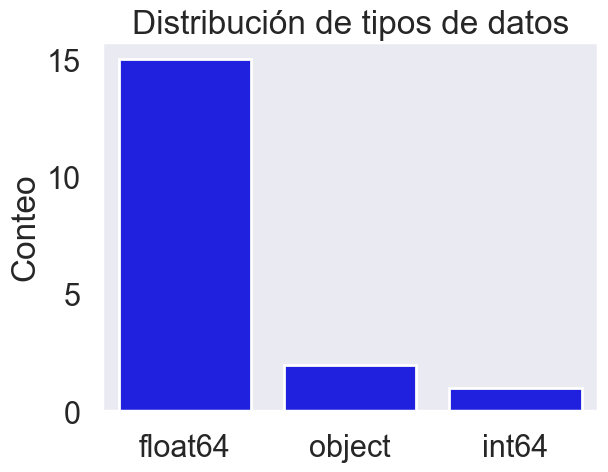

In [17]:
countries_in_df = df_new_cars.query('`GEO (Labels)` != "European Union - 27 countries (from 2020)"')['GEO (Labels)'].unique()

print(f'El conteo de países es de: \n{len(countries_in_df)}')

print(f'\nLos países disponibles son: \n{countries_in_df}')

print('\nTipos de datos y resumen general:')
df_new_cars.info()

dtype_counts = df_new_cars.dtypes.value_counts().reset_index()
dtype_counts.columns = ['dtype', 'count']

sns.barplot(data=dtype_counts, x='dtype', y='count', color='blue')
plt.title('Distribución de tipos de datos')
plt.ylabel('Conteo')
plt.xlabel(None)
plt.show()

#### Filas duplicadas y nulos por columna

Total de filas duplicadas:
0

Valores nulos por columna:
Plug-in hybrid diesel-electric      166
Plug-in hybrid petrol-electric      160
Biodiesel                           156
Bioethanol                          143
Hybrid diesel-electric              126
Bi-fuel                             118
Other                                96
Hybrid electric-petrol               88
Diesel (excluding hybrids)           72
Natural gas                          72
Petrol (excluding hybrids)           71
Liquefied petroleum gases (LPG)      67
Alternative energy                   46
GEO (Codes)                           0
GEO (Labels)                          0
Electricity                           0
TIME                                  0
Hydrogen and fuel cells               0
dtype: int64


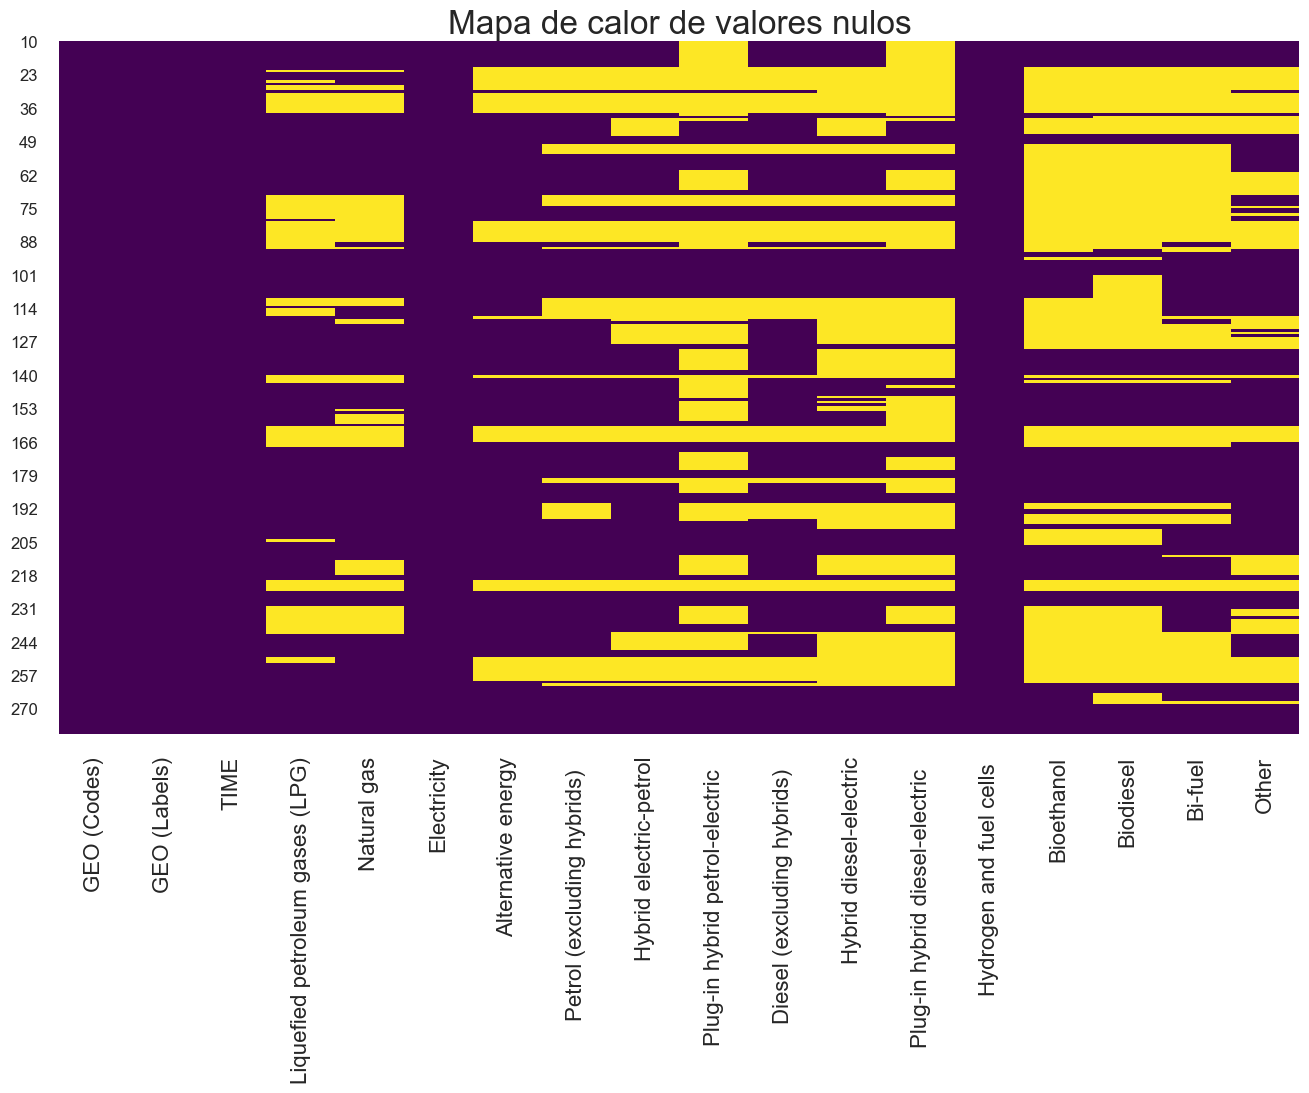

In [18]:
# Lista de los 27 países que forman parte de la Unión Europea (desde 2020)
European_Union_27_countries_from_2020 = [
    'Austria', 'Belgium', 'Bulgaria',
    'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland',
    'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy',
    'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland',
    'Portugal', 'Romania', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden']

# Filtrar los países que forman parte de la Unión Europea
df_new_cars_filtered = df_new_cars[df_new_cars['GEO (Labels)'].isin(
    European_Union_27_countries_from_2020)]

print('Total de filas duplicadas:')
print(df_new_cars_filtered.duplicated().sum())

print('\nValores nulos por columna:')
print(df_new_cars_filtered.isnull().sum().sort_values(ascending=False))

plt.figure(figsize=(16, 9))
sns.heatmap(df_new_cars_filtered.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.show()

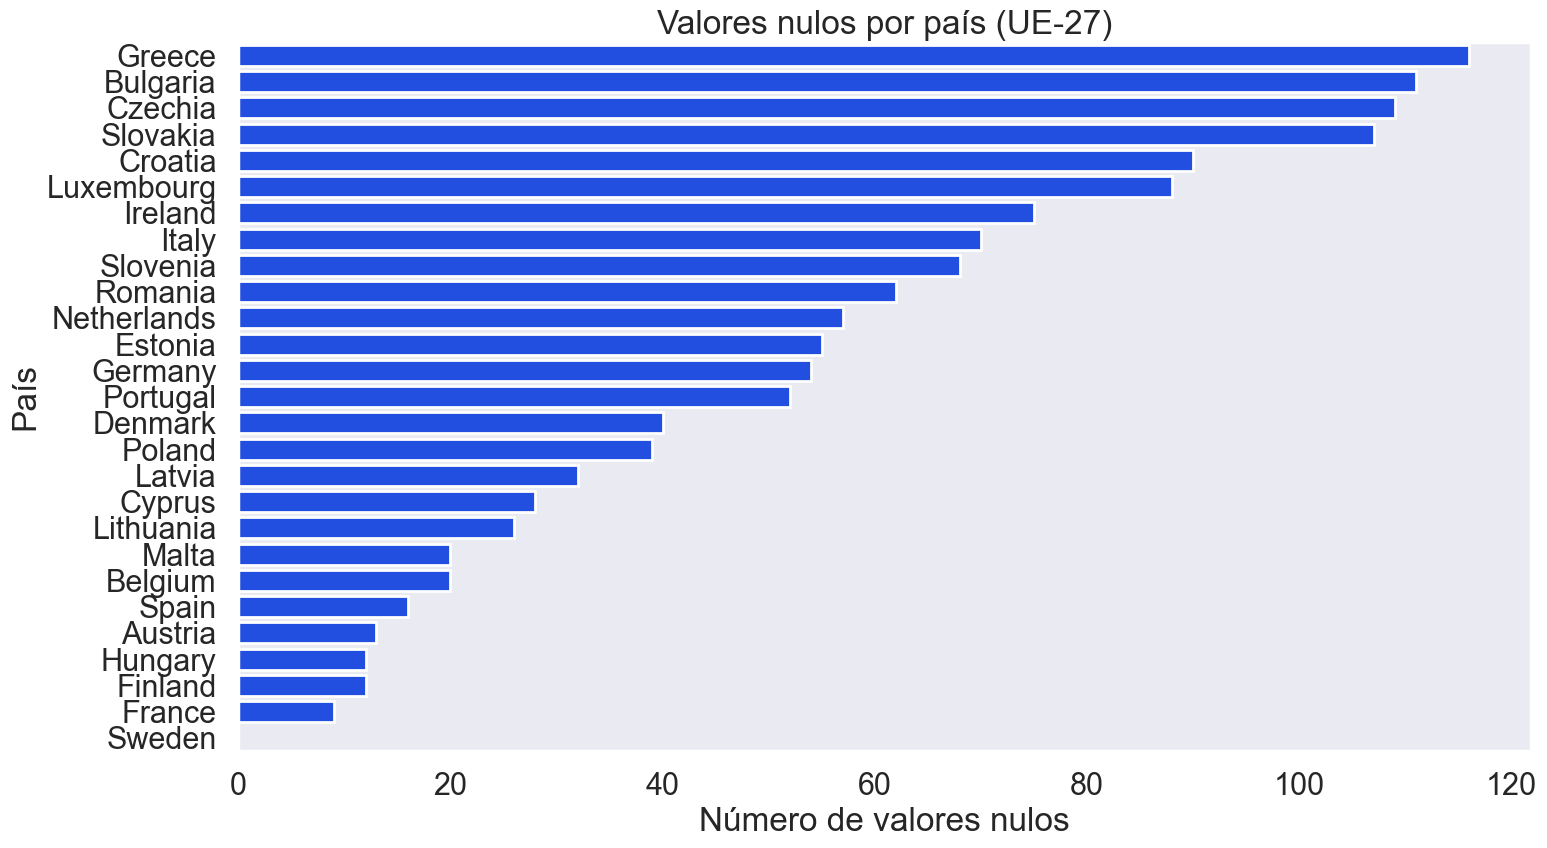

In [19]:
# Contar valores nulos por país (resultado = Serie con países en el índice)
nulos_por_pais = df_new_cars_filtered.isnull().groupby(df_new_cars_filtered['GEO (Labels)']).sum().sum(axis=1)

# Ordenar de mayor a menor
nulos_por_pais = nulos_por_pais.sort_values(ascending=False)

# Mostrar gráfico de barras
plt.figure(figsize=(16, 9), tight_layout=True)
sns.barplot(x=nulos_por_pais.values, y=nulos_por_pais.index)
plt.title('Valores nulos por país (UE-27)')
plt.xlabel('Número de valores nulos')
plt.ylabel('País')
plt.show()

#### Estadísticas descriptivas básicas

In [20]:
print('Estadísticas básicas (variables numéricas):')
df_new_cars_filtered.describe().round(1)

Estadísticas básicas (variables numéricas):


,TIME,Liquefied petroleum gases (LPG),Natural gas,Electricity,Alternative energy,Petrol (excluding hybrids),Hybrid electric-petrol,Plug-in hybrid petrol-electric,Diesel (excluding hybrids),Hybrid diesel-electric,Plug-in hybrid diesel-electric,Hydrogen and fuel cells,Bioethanol,Biodiesel,Bi-fuel,Other
count,270.0,203.0,198.0,270.0,224.0,199.0,182.0,110.0,198.0,144.0,104.0,270.0,127.0,114.0,152.0,174.0
mean,2017.5,6779.8,2811.1,11761.0,25009.4,206617.4,32564.1,20147.4,172340.7,8253.6,1493.3,14.8,22.7,0.8,2137.1,1078.1
std,2.9,25562.8,10286.1,42861.7,60246.4,349273.8,65365.4,49964.5,295930.7,22220.6,3829.6,67.5,110.3,4.5,6507.4,5266.4
min,2013.0,0.0,0.0,0.0,1.0,408.0,1.0,0.0,406.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2015.0,0.0,5.2,116.0,728.5,19197.5,1816.5,673.2,7727.0,22.2,21.8,0.0,0.0,0.0,0.0,0.0
50%,2017.5,1.0,53.5,833.0,3595.5,68405.0,8211.0,3517.5,39126.0,814.0,263.5,0.0,0.0,0.0,95.0,2.0
75%,2020.0,670.0,654.5,5075.2,16444.0,197423.0,29337.8,14887.8,173373.2,4121.8,1048.2,2.0,1.0,0.0,1088.5,230.5
max,2022.0,137096.0,72387.0,470559.0,488321.0,2142700.0,400850.0,345083.0,1336776.0,153135.0,23581.0,836.0,1062.0,34.0,46841.0,48063.0


### 🛠️ **Preparación y transformación de datos**

En los siguientes bloques se realizarán tareas de limpieza, normalización y reestructuración del dataframe para que esté listo para el análisis. Estas transformaciones tienen como propósito simplificar el dataframe, facilitar el análisis comparativo por tipo de motorización, y garantizar que los datos reflejen únicamente a la Unión Europea (27 países) de forma consolidada y comprensible.

1. __Filtrado geográfico__  
    Se filtrará el dataframe por los 27 países que pertenecen a la Unión Europea (UE-27). Además, se removerán temporalmente las filas correspondiente al total de la UE (`European Union - 27 countries (from 2020)`) para recalcularla manualmente más adelante con los datos actualizados.

2. __Reconstrucción del total para la UE__  
    Luego del filtrado de países se calcula el total de vehículos para la UE-27, sumando los valores por año.

3. __Renombrado y limpieza de columnas__  
    - Se limpiarán los nombres de columnas, eliminando espacios y caracteres problemáticos.
    - Se renombrarán columnas clave como `Petrol_(excluding_hybrids)` → `Gasolina` y `Diesel_(excluding_hybrids)` → `Diesel` para facilitar la lectura.
    - Se eliminará la columna `Alternative energy`.  
    _Nota: la columna `Alternative energy`, es una sumatoria de las columnas `Liquefied_petroleum_gas`, `Natural_Gas`, `Electricity`, `Hydrogen_and_fuel_cells`, `Bioethanol`, `Biosiesel`, `Bi-fuel` y `Other`, por lo que se descarta y construye una nueva categoría que no incluya a `Electricity` y `Hydrogen_and_fuel_cells`._

4. __Reagrupación de categorías energéticas__  
    - Se agruparán distintas columnas relacionadas con energías alternativas (LPG, gas natural, biocombustibles, bi-fuel) en una única columna llamada `Alternativos`.
    - De forma similar, se unifican las tecnologías eléctricas e híbridas en la nueva columna `Electrificados`.

#### Filtrado de países y limpieza básica

In [21]:
# Lista de los 27 países que forman parte de la Unión Europea (desde 2020)
European_Union_27_countries_from_2020 = [
    'Austria', 'Belgium', 'Bulgaria',
    'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland',
    'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy',
    'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland',
    'Portugal', 'Romania', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden']

# Filtrar por los países que forman parte de la Unión Europea
df_new_cars = df_new_cars[df_new_cars['GEO (Labels)'].isin(
    European_Union_27_countries_from_2020)]

# Limpiar nombres de columnas (quitar espacios y caracteres problemáticos)
df_new_cars.columns = df_new_cars.columns.str.strip().str.replace(' ', '_')

# Agrupar los datos por año sumando valores de los países miembros
df_new_cars = df_new_cars.groupby('TIME').sum().reset_index()

# Reordenar columna TIME
df_new_cars.insert(2, 'TIME', df_new_cars.pop('TIME'))

# Actualizar los valores del código y etiqueta para representar a la UE-27
df_new_cars['GEO_(Codes)'] = df_new_cars['GEO_(Codes)'].replace(
    'BEBGCZDKDEEEIEELESFRHRITCYLVLTLUHUMTNLATPLPTROSISKFISE', 'EU27_2020')
df_new_cars['GEO_(Labels)'] = df_new_cars['GEO_(Labels)'].replace(
    'BelgiumBulgariaCzechiaDenmarkGermanyEstoniaIrelandGreeceSpainFranceCroatiaItalyCyprusLatviaLithuaniaLuxembourgHungaryMaltaNetherlandsAustriaPolandPortugalRomaniaSloveniaSlovakiaFinlandSweden',
    'European Union - 27 countries (from 2020)')

# Rellenar valores nulos consigo mismos (aparentemente redundante, pero evita errores)
df_new_cars = df_new_cars.fillna(df_new_cars)

#Columnas a excluir de la converción.
exclude_cols = ['GEO_(Codes)', 'GEO_(Labels)', 'TIME']

# Detectar columnas de tipo float (y que no estén en la lista de exclusión)
cols_to_convert = [
    col for col in df_new_cars.select_dtypes(include='float').columns
    if col not in exclude_cols
]
# Convertir a int (si estás seguro de que no hay NaN)
df_new_cars[cols_to_convert] = df_new_cars[cols_to_convert].astype(int)

# Mostrar dataframe
df_new_cars.head()

,GEO_(Codes),GEO_(Labels),TIME,Liquefied_petroleum_gases_(LPG),Natural_gas,Electricity,Alternative_energy,Petrol_(excluding_hybrids),Hybrid_electric-petrol,Plug-in_hybrid_petrol-electric,Diesel_(excluding_hybrids),Hybrid_diesel-electric,Plug-in_hybrid_diesel-electric,Hydrogen_and_fuel_cells,Bioethanol,Biodiesel,Bi-fuel,Other
0,EU27_2020,European Union - 27 countries (from 2020),2013,127712,79897,21908,266653,1759604,90269,1274,2783435,15233,861,7,670,2,6617,30476
1,EU27_2020,European Union - 27 countries (from 2020),2014,137463,86343,30892,295899,2176478,90201,5422,3477677,10645,1073,21,604,6,8537,32428
2,EU27_2020,European Union - 27 countries (from 2020),2015,133943,70743,46641,296713,2618876,128297,12554,3664274,22120,863,126,347,1,8536,38006
3,EU27_2020,European Union - 27 countries (from 2020),2016,113317,49513,53544,279173,3175756,158323,19094,3882988,6174,1845,104,1086,0,10377,53711
4,EU27_2020,European Union - 27 countries (from 2020),2017,147922,39953,83778,289216,5755345,291713,62807,5424503,3900,2982,214,12,0,15250,6652


#### Renombrado y eliminación de columnas

In [22]:
# Eliminar columnas no informativas o redundantes
df_new_cars = df_new_cars.drop(['GEO_(Labels)', 'Alternative_energy'], axis=1)

# Renombrar columnas clave para mejorar la legibilidad
df_new_cars = df_new_cars.rename(columns={
    'GEO_(Codes)':'Geocódigos',
    'TIME':'Años',
    'Petrol_(excluding_hybrids)': 'Gasolina',
    'Diesel_(excluding_hybrids)': 'Diesel'})

#### Reagrupación de categorías energéticas

In [23]:
# Crear nueva columna agrupada con energías alternativas (gas, bio y bi-fuel)
df_new_cars['Alternativos'] = df_new_cars[[
    'Liquefied_petroleum_gases_(LPG)',
    'Natural_gas',
    'Bioethanol',
    'Biodiesel',
    'Bi-fuel',
    'Other']].sum(axis=1)

# Eliminar las columnas originales ya agrupadas
df_new_cars = df_new_cars.drop([
    'Liquefied_petroleum_gases_(LPG)',
    'Natural_gas',
    'Bioethanol',
    'Biodiesel',
    'Bi-fuel',
    'Other'], axis=1)

# Crear columna agrupada de tecnologías eléctricas e híbridas
df_new_cars['Electrificados'] = df_new_cars[[
    'Electricity',
    'Hydrogen_and_fuel_cells',
    'Hybrid_electric-petrol',
    'Hybrid_diesel-electric',
    'Plug-in_hybrid_petrol-electric',
    'Plug-in_hybrid_diesel-electric']].sum(axis=1)

# Eliminar las columnas originales ya agrupadas
df_new_cars = df_new_cars.drop([
    'Electricity',
    'Hydrogen_and_fuel_cells',
    'Hybrid_electric-petrol',
    'Hybrid_diesel-electric',
    'Plug-in_hybrid_petrol-electric',
    'Plug-in_hybrid_diesel-electric'], axis=1)

# Recalcular 'Total'
df_new_cars.insert(
    2,
    'Total',
    df_new_cars[[
        'Alternativos',
        'Electrificados',
        'Gasolina',
        'Diesel']].sum(axis=1))

# Mostrar resultado final
df_new_cars.head()

,Geocódigos,Años,Total,Gasolina,Diesel,Alternativos,Electrificados
0,EU27_2020,2013,4917965,1759604,2783435,245374,129552
1,EU27_2020,2014,6057790,2176478,3477677,265381,138254
2,EU27_2020,2015,6745327,2618876,3664274,251576,210601
3,EU27_2020,2016,7525832,3175756,3882988,228004,239084
4,EU27_2020,2017,11835031,5755345,5424503,209789,445394


#### Exportación del dataset limpio 💾

El dataframe transformado se guarda como archivo `.csv` en la carpeta `data/processed`. Esto permite reutilizar los datos ya procesados sin volver a ejecutar todos los pasos anteriores.

In [42]:
# Buscar la carpeta 'data/processed' desde el notebook actual
base_path = Path.cwd()
while not (base_path / "data" / "processed").exists() and base_path.parent != base_path:
    base_path = base_path.parent

output_dir = base_path / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "df_new_cars.csv"

df_new_cars.to_csv(output_path, index=False, encoding='utf-8')

### 📈 **Análisis visual e interpretación.**

#### __¿Cómo ha crecido y cambiado la matriculación de coches nuevos en Europa según el tipo de motor?__

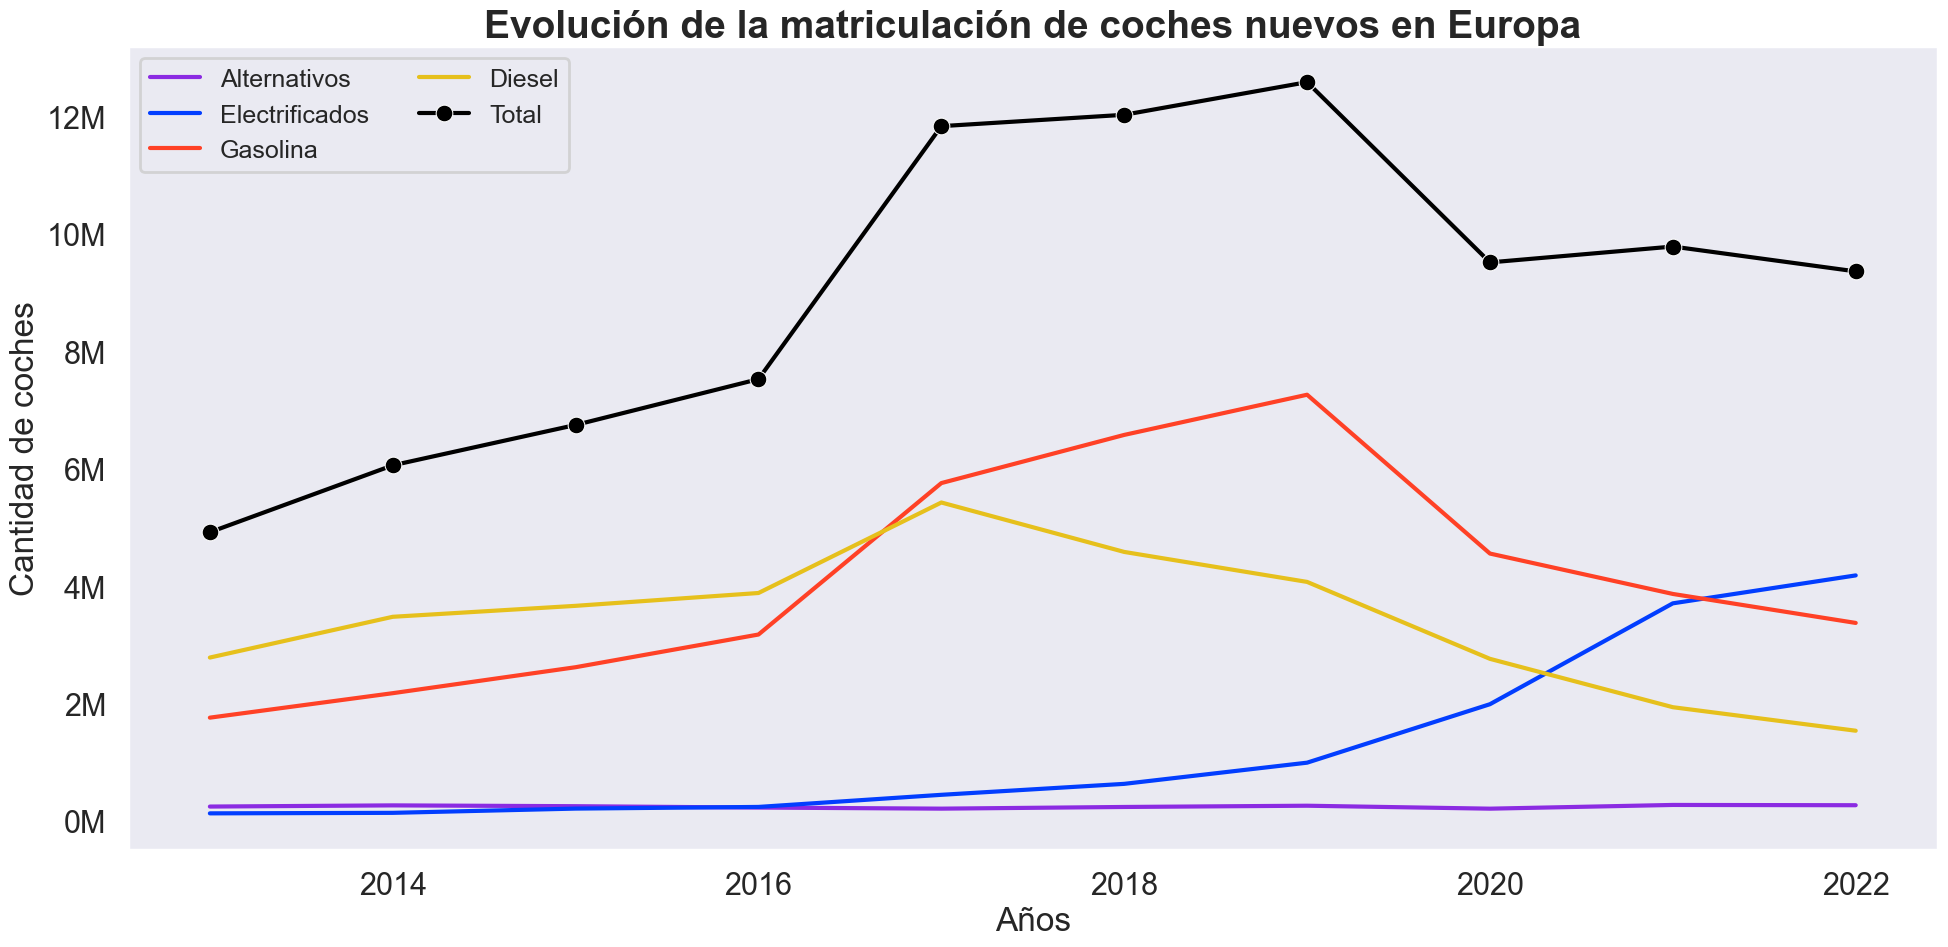

In [25]:
custom_palette = {
    'Alternativos': '#8b2be2',
    'Electrificados': '#023eff',
    'Gasolina': '#ff4126',
    'Diesel': '#e6c01c'}

# Graficar las categorías individuales
plt.figure(figsize=(20, 10), tight_layout=True)
sns.lineplot(
    data=df_new_cars.melt(
        id_vars='Años',
        value_vars=[
            'Alternativos',
            'Electrificados',
            'Gasolina',
            'Diesel'],
        var_name='Motor',
        value_name='Cantidad de coches'),
    x='Años',
    y='Cantidad de coches',
    hue='Motor',
    palette=custom_palette,
    errorbar=None)
# Graficar el total por encima
sns.lineplot(
    data=df_new_cars,
    x='Años',
    y='Total',
    label='Total',
    marker='o',
    color='black')
plt.title(
    'Evolución de la matriculación de coches nuevos en Europa',
    fontsize=28, fontweight='bold')
plt.ylabel('Cantidad de coches')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))
plt.legend(
    loc='upper left',
    ncol=2, fontsize=18)
plt.show()

El gráfico revela un punto de inflexión en las tendencias de compra de automóviles en Europa. Entre 2013 y 2017, la matriculación de coches nuevos creció de manera generalizada, con _gasolina_ y _diésel_ como protagonistas. Sin embargo, a partir de 2017 se observa un cambio estructural, el total de matriculaciones se ve afectado con un declive a partir de 2019.
  
- _Gasolina_: alcanzó su pico en 2019 y desde entonces ha entrado en descenso.  
- _Diésel_: perdió fuerza aún antes, con una caída sostenida desde 2017.  
- _Electrificados_: muestran un crecimiento exponencial desde 2017, hasta el punto de superar a los diesel en 2021 y los gasolina en 2022.  
- _Alternativos_: mantienen una presencia reducida y estable.

En conjunto, el gráfico muestra que la compra de coches nuevos en Europa se orienta progresivamente hacia la electrificación, mientras los motores tradicionales pierden protagonismo.

#### __¿Cómo ha evolucionado la matriculación de nuevos coches electrificados en Europa?__

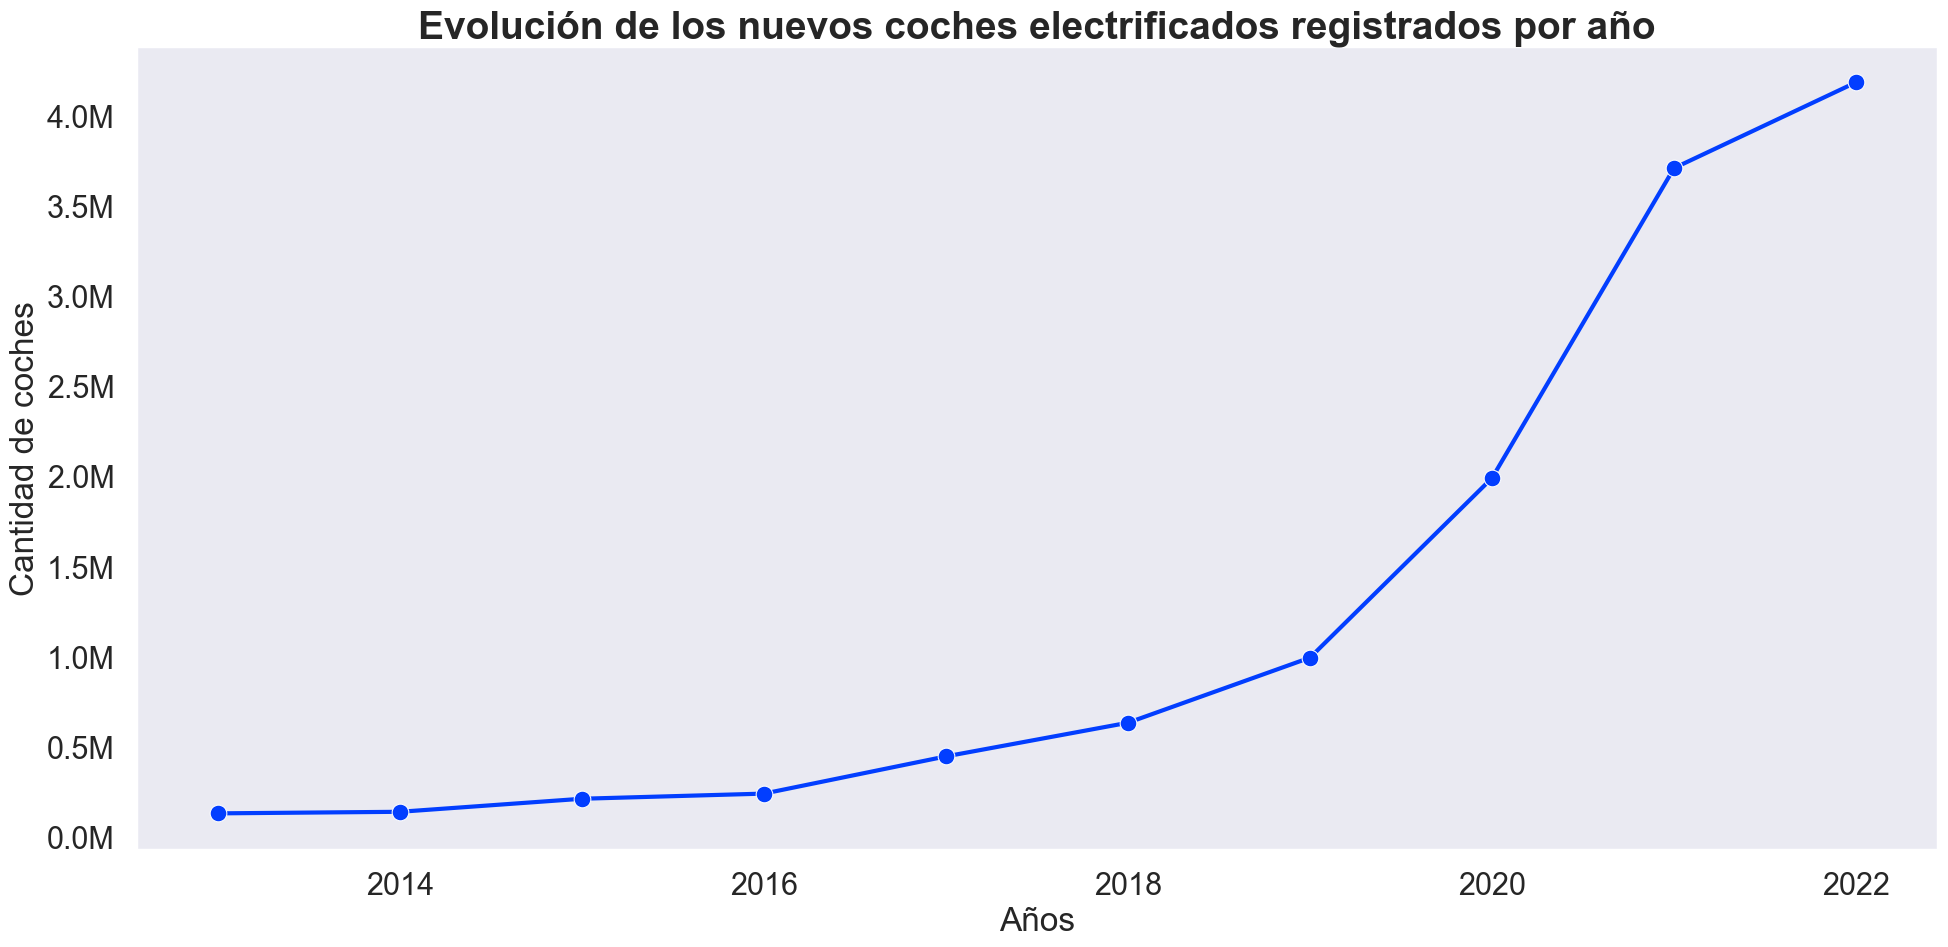

In [26]:
plt.figure(figsize=(20, 10), tight_layout=True)
ax = sns.lineplot(
    data=df_new_cars.melt(
        id_vars='Años',
        value_vars='Electrificados',
        var_name='Motor',
        value_name='Cantidad de coches'),
    x='Años',
    y='Cantidad de coches',
    color='#023eff',
    marker='o')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.title(
    'Evolución de los nuevos coches electrificados registrados por año',
    fontdict={'fontsize':28, 'fontweight':'bold'})
plt.show()

El gráfico muestra un crecimiento sostenido y acelerado en la incorporación de coches _electrificados_ al mercado europeo.
Entre 2013 y 2016, el número de nuevos vehículos _electrificados_ era marginal, con un crecimiento moderado. Sin embargo, a partir de 2017 se observa una ruptura clara de tendencia, donde la matriculación empieza a aumentar de forma exponencial.

En resumen, el gráfico refleja una transición acelerada hacia la movilidad eléctrica, con los coches _electrificados_ multiplicándose más de veinte veces.

#### __¿Cómo ha cambiado la matriculación de coches nuevos en Europa entre 2022 y 2013?__

In [27]:
df_2013 = df_new_cars[df_new_cars['Años'] == 2013]
df_2022 = df_new_cars[df_new_cars['Años'] == 2022]

columns = [
    'Alternativos',
    'Electrificados',
    'Gasolina',
    'Diesel']

data_2013 = df_2013[columns].sum()
data_2022 = df_2022[columns].sum()

rows = []
for col in columns:
    rows.append({
        'Año': '2013',
        'Motor': col,
        'Valor': data_2013[col]})
for col in columns:
    rows.append({
        'Año': '2022',
        'Motor': col,
        'Valor': data_2022[col]})

df_plot = pd.DataFrame(rows)

fig = px.treemap(
    df_plot,
    path=['Año', 'Motor'],
    values='Valor',
    color='Valor',
    color_continuous_scale='Portland',
    title='Nuevos coches matriculados por tipo de motor (2022 vs 2013)')
fig.update_layout(
    width=1600,
    height=900,
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=18, color='black'),
    title=dict(
        font=dict(size=28, color='black', weight=800),
        x=0.5, xanchor='center'))
fig.show()


El gráfico refleja con claridad la transformación en la matriculación de nuevos coches durante la última década. El parque automotor sigue dominado por _gasolina_ y _diésel_, pero los vehículos _electrificados_ han multiplicado su presencia en comparación con 2013, donde su presencia era prácticamente marginal.

Vemos también que la proporción empieza a diversificarse. Los _electrificados_ muestran un fuerte crecimiento convietiendose en 2022 en los coches con más matriculaciones, superando a _gasolina_ y diesel, y los _alternativos_ mantienen su peso, aunque de forma moderada.

En conjunto, el treemap revela que el parque motor europeo entró en una etapa de transición tecnológica, donde las nuevas formas de propulsión han ganado espacio frente a los motores tradicionales.

___

## 🚙 **Automóviles, por tipo de energía motriz**

### 📑 **Dataframe utilizado**
__Nombre__: _Passenger cars, by type of motor energy_ (`road_eqs_carpda`)  
__Fuente oficial__: [Eurostat](https://ec.europa.eu/eurostat)  
__Acceso a los datos__: [Eurostat - Data Browser](https://ec.europa.eu/eurostat/databrowser/view/road_eqs_carpda__custom_17309262/default/table?lang=en)

#### Descripción general del dataframe

Este conjunto de datos proporciona información sobre el número total de turismos registrados, clasificados según el tipo de energía del motor (fuel type).

- Frecuencia temporal: Anual (A)
- Unidad de medida: Número (NR)
- Cobertura geográfica: Países de la Unión Europea
- Tipos de motor:
    - Gasolina
    - Diésel
    - Vehículos eléctricos de batería (BEV)
    - Híbridos (enchufables y no enchufables de gasolina o diésel)
    - Gas natural, GLP, y biocombustibles.

#### Notas adicionales

Este dataframe es útil para analizar la evolución del parque automotor en Europa, especialmente en el contexto de la transición energética hacia fuentes menos contaminantes.

#### Carga de datos 🧭

En este paso se carga el archivo Excel que contiene los datos del número total de turismos registrados por tipo de motorización. El archivo debe estar ubicado en la carpeta `data/raw`.

In [28]:
# Buscar la carpeta 'data/raw' hacia arriba desde el notebook actual
base_path = Path.cwd()
while not (base_path / "data" / "raw").exists() and base_path.parent != base_path:
    base_path = base_path.parent

file_path = base_path / "data" / "raw" / "road_eqs_carpda__custom_15714409_page_spreadsheet.xlsx"

df_cars_park = pd.read_excel(file_path, sheet_name='Data')
df_cars_park.head()

,GEO (Codes),GEO (Labels),TIME,Total,Liquefied petroleum gases (LPG),Natural gas,Electricity,Alternative energy,Petrol (excluding hybrids),Hybrid electric-petrol,Plug-in hybrid petrol-electric,Diesel (excluding hybrids),Hybrid diesel-electric,Plug-in hybrid diesel-electric,Hydrogen and fuel cells,Bioethanol,Biodiesel,Bi-fuel,Other
0,EU27_2020,European Union - 27 countries (from 2020),2013,221705164.0,NaN,NaN,50278.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,NaN,NaN,NaN
1,EU27_2020,European Union - 27 countries (from 2020),2014,224317337.0,NaN,NaN,76277.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,NaN,NaN,NaN,NaN
2,EU27_2020,European Union - 27 countries (from 2020),2015,225651590.0,NaN,NaN,120093.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,222.0,NaN,NaN,NaN,NaN
3,EU27_2020,European Union - 27 countries (from 2020),2016,230249119.0,NaN,NaN,168279.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,322.0,NaN,NaN,NaN,NaN
4,EU27_2020,European Union - 27 countries (from 2020),2017,236047946.0,NaN,NaN,246099.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,659.0,NaN,NaN,NaN,NaN


### 🔎 **Diagnóstico inicial de los datos (EDA)**

En esta sección se realiza una inspección inicial del dataframe crudo, para comprender su estructura, calidad y contenido antes de aplicar transformaciones.

Comprobaré:
- Tipos de datos
- Presencia de valores nulos.
- Duplicados.
- Estadísticas descriptivas básicas.


#### Información general del dataframe

El conteo de países es de: 
41

Los países disponibles son: 
['Belgium' 'Bulgaria' 'Czechia' 'Denmark' 'Germany' 'Estonia' 'Ireland'
 'Greece' 'Spain' 'France' 'Croatia' 'Italy' 'Cyprus' 'Latvia' 'Lithuania'
 'Luxembourg' 'Hungary' 'Malta' 'Netherlands' 'Austria' 'Poland'
 'Portugal' 'Romania' 'Slovenia' 'Slovakia' 'Finland' 'Sweden' 'Iceland'
 'Liechtenstein' 'Norway' 'Switzerland' 'United Kingdom'
 'Bosnia and Herzegovina' 'Montenegro' 'Moldova' 'North Macedonia'
 'Georgia' 'Albania' 'Serbia' 'Türkiye' 'Kosovo*']

Tipos de datos y resumen general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   GEO (Codes)                       420 non-null    object 
 1   GEO (Labels)                      420 non-null    object 
 2   TIME                              420 non-null    int64  
 3   Total              

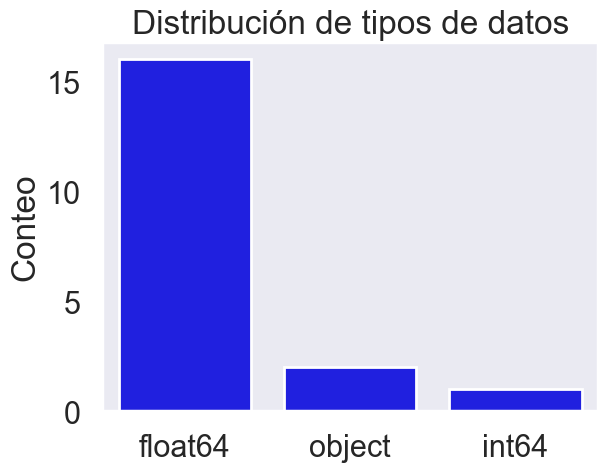

In [29]:
countries_in_df = df_cars_park.query('`GEO (Labels)` != "European Union - 27 countries (from 2020)"')['GEO (Labels)'].unique()

print(f'El conteo de países es de: \n{len(countries_in_df)}')

print(f'\nLos países disponibles son: \n{countries_in_df}')

print('\nTipos de datos y resumen general:')
df_cars_park.info()

dtype_counts = df_cars_park.dtypes.value_counts().reset_index()
dtype_counts.columns = ['dtype', 'count']

sns.barplot(data=dtype_counts, x='dtype', y='count', color='blue')
plt.title('Distribución de tipos de datos')
plt.ylabel('Conteo')
plt.xlabel(None)
plt.show()

#### Filas duplicadas y nulos por columna

Total de filas duplicadas:
0

Valores nulos por columna:
Plug-in hybrid petrol-electric      156
Plug-in hybrid diesel-electric      152
Biodiesel                           122
Bioethanol                          120
Bi-fuel                             107
Hybrid diesel-electric               95
Hybrid electric-petrol               89
Diesel (excluding hybrids)           62
Petrol (excluding hybrids)           56
Other                                49
Liquefied petroleum gases (LPG)      37
Natural gas                          37
Alternative energy                   34
GEO (Codes)                           0
GEO (Labels)                          0
TIME                                  0
Electricity                           0
Total                                 0
Hydrogen and fuel cells               0
dtype: int64


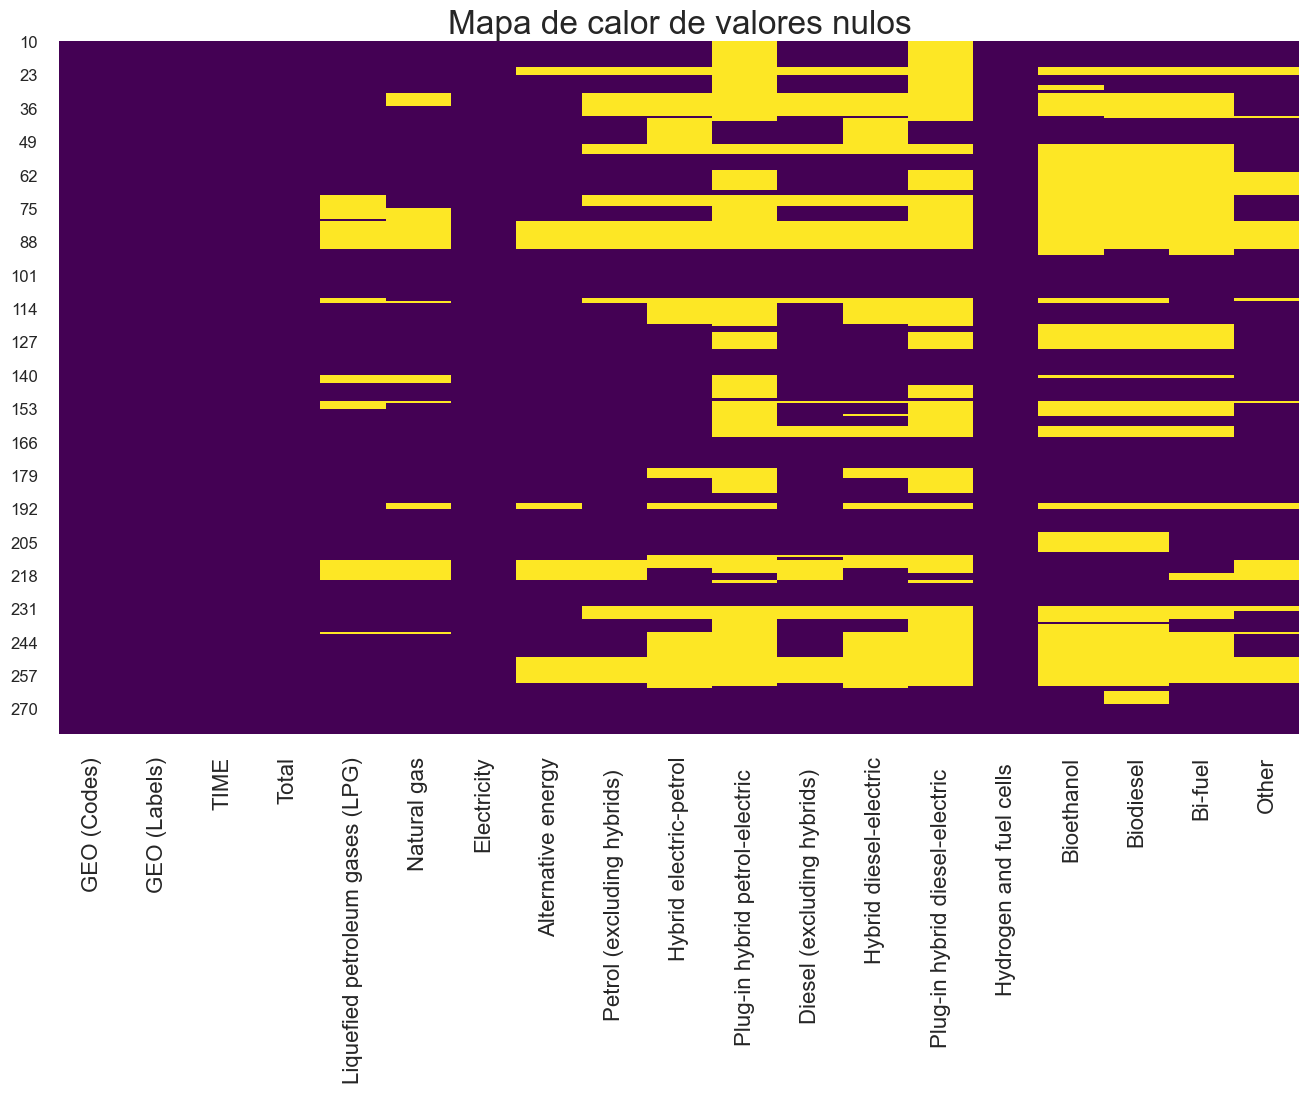

In [30]:
# Lista de los 27 países que forman parte de la Unión Europea (desde 2020)
European_Union_27_countries_from_2020 = [
    'Austria', 'Belgium', 'Bulgaria',
    'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland',
    'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy',
    'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland',
    'Portugal', 'Romania', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden']

# Filtrar los países que forman parte de la Unión Europea
df_cars_park_filtered = df_cars_park[df_cars_park['GEO (Labels)'].isin(
    European_Union_27_countries_from_2020)]

print('Total de filas duplicadas:')
print(df_cars_park_filtered.duplicated().sum())

print('\nValores nulos por columna:')
print(df_cars_park_filtered.isnull().sum().sort_values(ascending=False))

plt.figure(figsize=(16, 9))
sns.heatmap(df_cars_park_filtered.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.show()

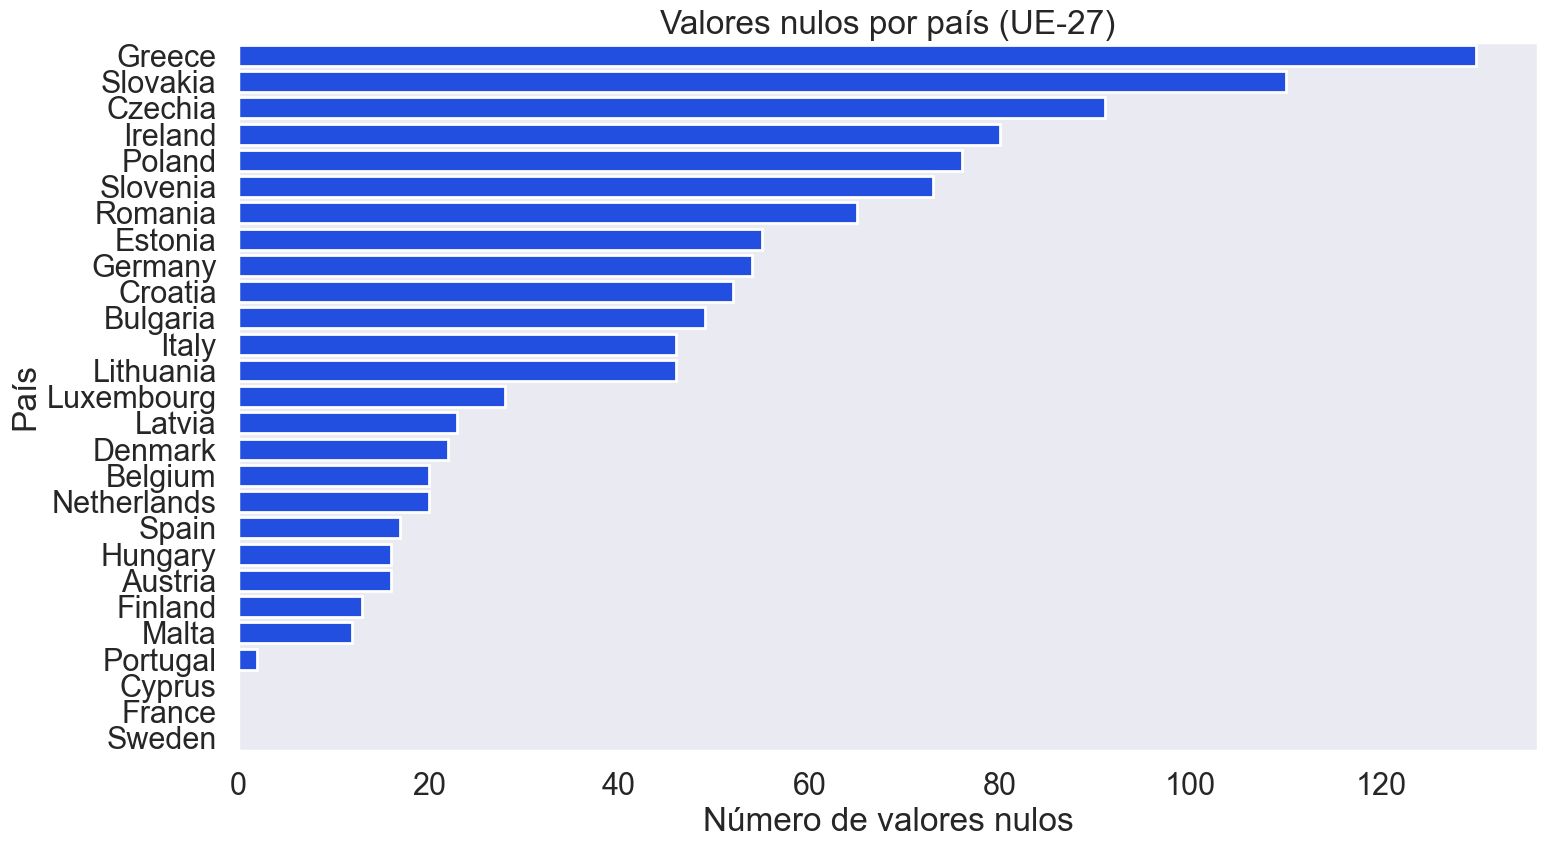

In [31]:
# Contar valores nulos por país (resultado = Serie con países en el índice)
nulos_por_pais = df_cars_park_filtered.isnull().groupby(df_cars_park_filtered['GEO (Labels)']).sum().sum(axis=1)

# Ordenar de mayor a menor
nulos_por_pais = nulos_por_pais.sort_values(ascending=False)

# Mostrar gráfico de barras
plt.figure(figsize=(16, 9), tight_layout=True)
sns.barplot(x=nulos_por_pais.values, y=nulos_por_pais.index)
plt.title('Valores nulos por país (UE-27)')
plt.xlabel('Número de valores nulos')
plt.ylabel('País')
plt.show()

#### Estadísticas descriptivas básicas

In [32]:
print('Estadísticas básicas (variables numéricas):')
df_cars_park_filtered.describe().round(1)

Estadísticas básicas (variables numéricas):


,TIME,Total,Liquefied petroleum gases (LPG),Natural gas,Electricity,Alternative energy,Petrol (excluding hybrids),Hybrid electric-petrol,Plug-in hybrid petrol-electric,Diesel (excluding hybrids),Hybrid diesel-electric,Plug-in hybrid diesel-electric,Hydrogen and fuel cells,Bioethanol,Biodiesel,Bi-fuel,Other
count,270.0,270.0,233.0,233.0,270.0,236.0,214.0,181.0,114.0,208.0,175.0,118.0,270.0,150.0,148.0,163.0,221.0
mean,2017.5,8791653.7,167523.3,45087.9,28365.6,283299.7,4305603.3,111149.0,47676.7,3870458.6,17155.0,3594.3,36.4,3756.2,8.7,25132.5,27205.6
std,2.9,12711558.0,553187.2,186351.3,93237.4,739416.5,6610359.7,214692.9,106018.8,6263226.9,47758.4,8551.6,170.7,15684.5,28.9,44300.6,59432.9
min,2013.0,256096.0,0.0,0.0,0.0,6.0,122019.0,0.0,0.0,14930.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2015.0,1498966.5,5.0,93.0,585.8,9839.5,449680.5,5031.0,787.2,548827.2,92.0,23.8,0.0,0.0,0.0,0.0,6.0
50%,2017.5,3657786.5,57.0,562.0,2946.5,50124.0,2064550.0,26096.0,5385.0,1129427.5,2000.0,269.0,0.0,26.5,0.0,2915.0,3835.0
75%,2020.0,6036489.8,47651.0,5219.0,13859.0,169762.8,3109538.8,110302.0,55827.5,2823265.0,7982.5,2968.0,9.8,126.0,1.2,29835.0,17527.0
max,2022.0,48763036.0,2904072.0,984964.0,1013009.0,4036762.0,31464680.0,1384340.0,802371.0,23840395.0,415358.0,62162.0,2071.0,156825.0,159.0,233636.0,337471.0


### 🛠️ **Preparación y transformación de datos**

En los siguientes bloques se realizarán tareas de limpieza, normalización y reestructuración del dataframe para que esté listo para el análisis. Estas transformaciones tienen como propósito simplificar el dataframe, facilitar el análisis comparativo por tipo de motorización, y garantizar que los datos reflejen únicamente a la Unión Europea (27 países) de forma consolidada y comprensible.

1. __Filtrado geográfico__  
    Se filtrará el dataframe por los 27 países que pertenecen a la Unión Europea (UE-27). Además, se removerán temporalmente las filas correspondiente al total de la UE (`European Union - 27 countries (from 2020)`) para recalcularla manualmente más adelante con los datos actualizados.

4. __Reconstrucción del total para la UE__  
    Luego del filtrado de países se calcula el total de vehículos para la UE-27, sumando los valores por año.

2. __Renombrado y limpieza de columnas__  
    - Se limpiarán los nombres de columnas, eliminando espacios y caracteres problemáticos.
    - Se renombrarán columnas clave como `Petrol_(excluding_hybrids)` → `Gasolina` y `Diesel_(excluding_hybrids)` → `Diesel` para facilitar la lectura.
    - Se eliminarán las columnas `Total` y `Alternative energy`. Se recalculará la columna `Total` por inconcistencia con los datos presentes en el dataframe.  
    _Nota: la columna `Alternative energy`, es una sumatoria de las columnas `Liquefied_petroleum_gas`, `Natural_Gas`, `Electricity`, `Hydrogen_and_fuel_cells`, `Bioethanol`, `Biosiesel`, `Bi-fuel` y `Other`, por lo que se descarta y construye una nueva categoría que no incluya a `Electricity` y `Hydrogen_and_fuel_cells`._

3. __Reagrupación de categorías energéticas__  
    - Se agruparán distintas columnas relacionadas con energías alternativas (LPG, gas natural, biocombustibles, bi-fuel) en una única columna llamada `Alternativos`.
    - De forma similar, se unifican las tecnologías eléctricas e híbridas en la nueva columna `Electrificados`.

#### Filtrado de países y limpieza básica

In [33]:
# Lista de los 27 países que forman parte de la Unión Europea (desde 2020)
European_Union_27_countries_from_2020 = [
    'Austria', 'Belgium', 'Bulgaria',
    'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland',
    'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy',
    'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland',
    'Portugal', 'Romania', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden']

# Filtrar por los países que forman parte de la Unión Europea
df_cars_park = df_cars_park[df_cars_park['GEO (Labels)'].isin(
    European_Union_27_countries_from_2020)]

# Limpiar nombres de columnas (quitar espacios y caracteres problemáticos)
df_cars_park.columns = df_cars_park.columns.str.strip().str.replace(' ', '_')

# Agrupar los datos por años sumando los valores de los países miembros
df_cars_park = df_cars_park.groupby('TIME').sum().reset_index()

# Reposicionar la columna TIME
df_cars_park.insert(2, 'TIME', df_cars_park.pop('TIME'))

# Actualizar los valores del geocódigo y la geoetiqueta para representar a la Unión Europea
df_cars_park['GEO_(Codes)'] = df_cars_park['GEO_(Codes)'].replace(
    'BEBGCZDKDEEEIEELESFRHRITCYLVLTLUHUMTNLATPLPTROSISKFISE', 'EU27_2020')
df_cars_park['GEO_(Labels)'] = df_cars_park['GEO_(Labels)'].replace(
    'BelgiumBulgariaCzechiaDenmarkGermanyEstoniaIrelandGreeceSpainFranceCroatiaItalyCyprusLatviaLithuaniaLuxembourgHungaryMaltaNetherlandsAustriaPolandPortugalRomaniaSloveniaSlovakiaFinlandSweden',
    'European Union - 27 countries (from 2020)')

# Rellenar valores nulos consigo mismos (aparentemente redundante, pero evita errores)
df_cars_park = df_cars_park.fillna(df_cars_park)

#Columnas a excluir de la converción.
exclude_cols = ['GEO_(Codes)', 'GEO_(Labels)', 'TIME']

# Detectar columnas de tipo float (y que no estén en la lista de exclusión)
cols_to_convert = [
    col for col in df_cars_park.select_dtypes(include='float').columns
    if col not in exclude_cols
]
# Convertir a int (si estás seguro de que no hay NaN)
df_cars_park[cols_to_convert] = df_cars_park[cols_to_convert].astype(int)

# Mostrar dataframe
df_cars_park.head()

,GEO_(Codes),GEO_(Labels),TIME,Total,Liquefied_petroleum_gases_(LPG),Natural_gas,Electricity,Alternative_energy,Petrol_(excluding_hybrids),Hybrid_electric-petrol,Plug-in_hybrid_petrol-electric,Diesel_(excluding_hybrids),Hybrid_diesel-electric,Plug-in_hybrid_diesel-electric,Hydrogen_and_fuel_cells,Bioethanol,Biodiesel,Bi-fuel,Other
0,EU27_2020,European Union - 27 countries (from 2020),2013,221705164,5704274,880229,50278,7658422,67795426,171332,30874,36683521,27910,1043,39,29326,2,317733,714507
1,EU27_2020,European Union - 27 countries (from 2020),2014,224317337,5851232,945716,76277,7782730,76912591,295448,36579,71752025,41249,1975,61,32771,62,311138,932856
2,EU27_2020,European Union - 27 countries (from 2020),2015,225651590,3016880,1000160,120093,4912311,66433065,503658,110698,68391653,75350,16843,222,35734,74,310903,627710
3,EU27_2020,European Union - 27 countries (from 2020),2016,230249119,3068760,1015628,168279,5322524,68636414,683205,144527,71210778,81955,20996,322,36890,73,385367,694920
4,EU27_2020,European Union - 27 countries (from 2020),2017,236047946,3144012,1032539,246099,5278948,100676997,1148380,221503,90375941,95120,24697,659,37257,67,374257,494892


#### Renombrado y eliminación de columnas

In [34]:
# Eliminar columnas no informativas o redundantes
df_cars_park = df_cars_park.drop(['GEO_(Labels)', 'Total', 'Alternative_energy'], axis=1)

# Renombrar columnas clave para mejorar la legibilidad
df_cars_park = df_cars_park.rename(columns={
    'GEO_(Codes)':'Geocódigos',
    'TIME':'Años',
    'Petrol_(excluding_hybrids)': 'Gasolina',
    'Diesel_(excluding_hybrids)': 'Diesel'})

#### Reagrupación de categorías energéticas

In [35]:
# Crear nueva columna agrupada con energías alternativas (gas, bio y bi-fuel)
df_cars_park['Alternativos'] = df_cars_park[[
    'Liquefied_petroleum_gases_(LPG)',
    'Natural_gas',
    'Bioethanol',
    'Biodiesel',
    'Bi-fuel',
    'Other']].sum(axis=1)

# Eliminar las columnas originales ya agrupadas
df_cars_park = df_cars_park.drop([
    'Liquefied_petroleum_gases_(LPG)',
    'Natural_gas',
    'Bioethanol',
    'Biodiesel',
    'Bi-fuel',
    'Other'], axis=1)

# Crear columna agrupada de tecnologías eléctricas e híbridas
df_cars_park['Electrificados'] = df_cars_park[[
    'Electricity',
    'Hydrogen_and_fuel_cells',
    'Hybrid_electric-petrol',
    'Hybrid_diesel-electric',
    'Plug-in_hybrid_petrol-electric',
    'Plug-in_hybrid_diesel-electric']].sum(axis=1)

# Eliminar las columnas originales ya agrupadas
df_cars_park = df_cars_park.drop([
    'Electricity',
    'Hydrogen_and_fuel_cells',
    'Hybrid_electric-petrol',
    'Hybrid_diesel-electric',
    'Plug-in_hybrid_petrol-electric',
    'Plug-in_hybrid_diesel-electric'], axis=1)

# Recalcular 'Total'
df_cars_park.insert(
    2,
    'Total',
    df_cars_park[[
        'Alternativos',
        'Electrificados',
        'Gasolina',
        'Diesel']].sum(axis=1))

# Mostrar resultado final
df_cars_park.head()

,Geocódigos,Años,Total,Gasolina,Diesel,Alternativos,Electrificados
0,EU27_2020,2013,112406494,67795426,36683521,7646071,281476
1,EU27_2020,2014,157189980,76912591,71752025,8073775,451589
2,EU27_2020,2015,140643043,66433065,68391653,4991461,826864
3,EU27_2020,2016,146148114,68636414,71210778,5201638,1099284
4,EU27_2020,2017,197872420,100676997,90375941,5083024,1736458


#### Exportación del dataset limpio 💾

El dataframe transformado se guarda como archivo `.csv` en la carpeta `data/processed`. Esto permite reutilizar los datos ya procesados sin volver a ejecutar todos los pasos anteriores.

In [43]:
# Buscar la carpeta 'data/processed' desde el notebook actual
base_path = Path.cwd()
while not (base_path / "data" / "processed").exists() and base_path.parent != base_path:
    base_path = base_path.parent

output_dir = base_path / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "df_cars_park.csv"

df_cars_park.to_csv(output_path, index=False, encoding='utf-8')

### 📈 **Análisis visual e interpretación.**

#### __¿Cómo ha crecido y cambiado la composición del parque automotor en Europa?__

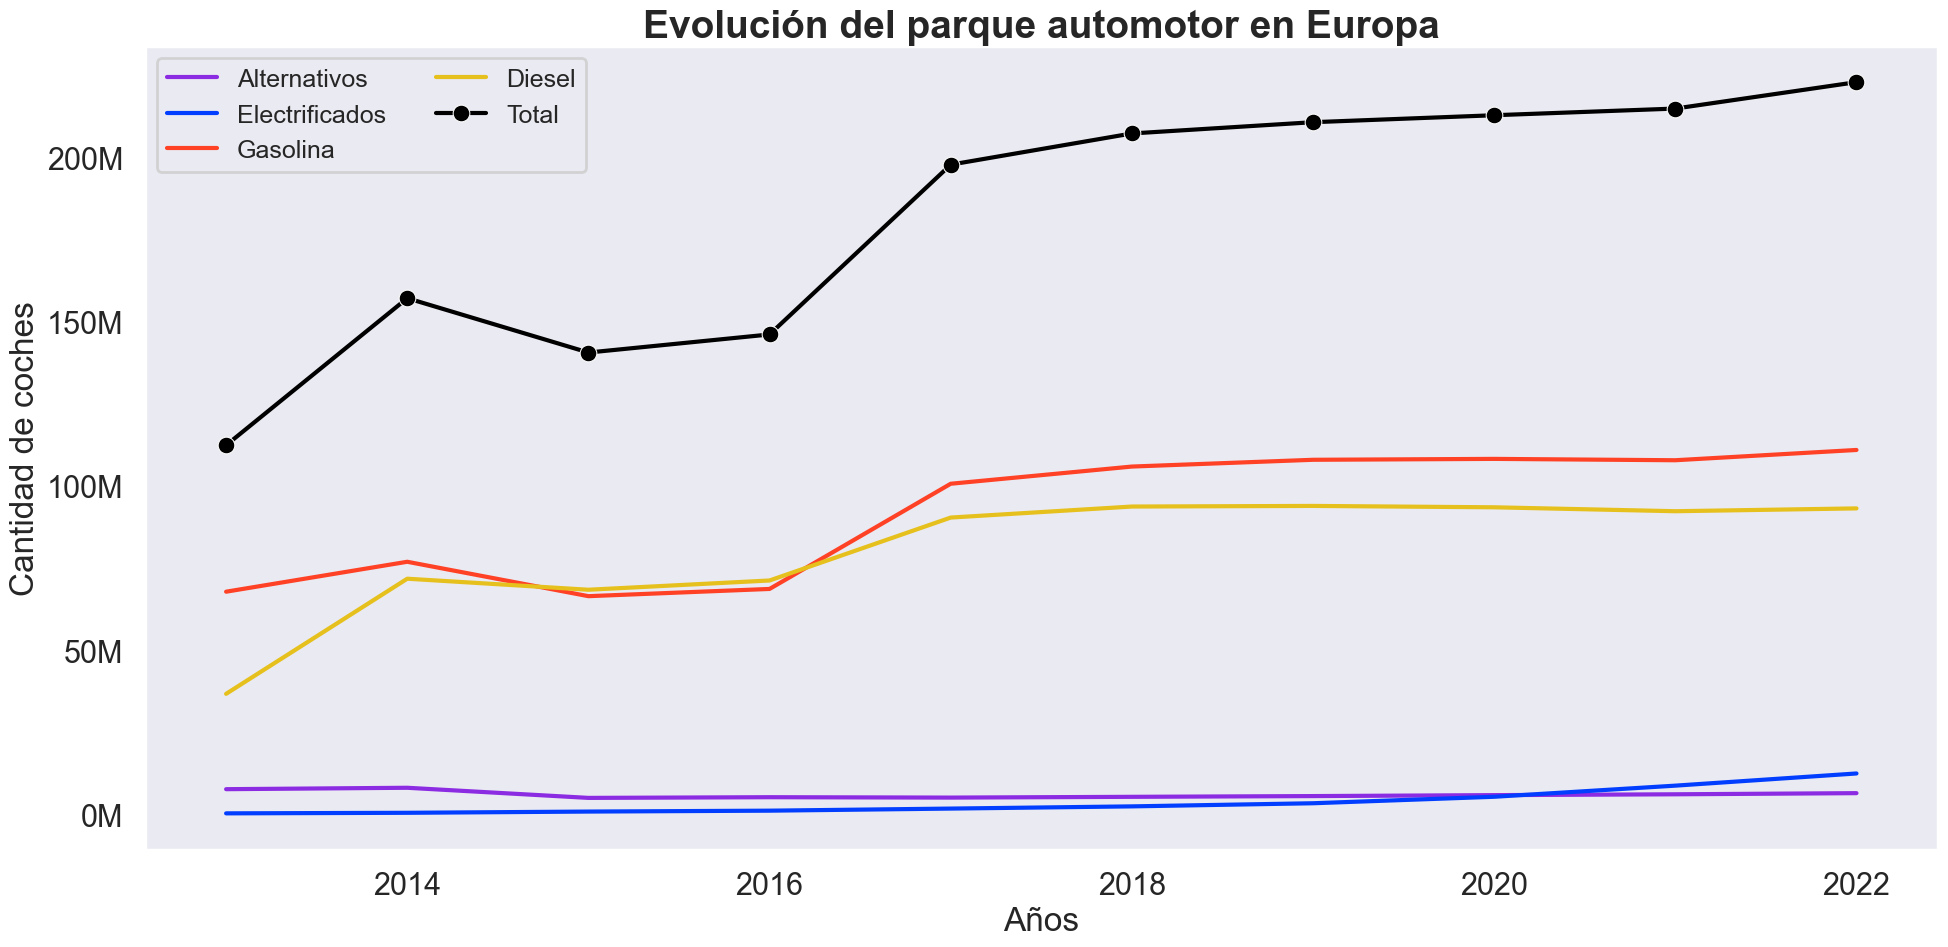

In [37]:
custom_palette = {
    'Alternativos': '#8b2be2',
    'Electrificados': '#023eff',
    'Gasolina': '#ff4126',
    'Diesel': '#e6c01c'}

# Graficar las categorías individuales
plt.figure(figsize=(20, 10), tight_layout=True)
sns.lineplot(
    data=df_cars_park.melt(
        id_vars='Años',
        value_vars=[
            'Alternativos',
            'Electrificados',
            'Gasolina',
            'Diesel'],
        var_name='Motor',
        value_name='Cantidad de coches'),
    x='Años',
    y='Cantidad de coches',
    hue='Motor',
    palette=custom_palette,
    errorbar=None)
# Graficar el total por encima
sns.lineplot(
    data=df_cars_park,
    x='Años',
    y='Total',
    label='Total',
    marker='o',
    color='black')
plt.title(
    'Evolución del parque automotor en Europa',
    fontsize=28, fontweight='bold')
plt.ylabel('Cantidad de coches')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))
plt.legend(
    loc='upper left',
    ncol=2, fontsize=18)
plt.show()

El parque automotor europeo casi se duplicó en una década, pasando de poco más de 110 millones de coches en 2013 a superar los 220 millones en 2022. La flota sigue dominada por los motores de combustión (_gasolina_ y _diésel_), que representan la mayoría de vehículos, aunque su crecimiento se ha estabilizado en los últimos años.

Pero a partir de 2017 se observa un crecimiento notable de los coches _electrificados_, que comienzan a ganar presencia de manera acelerada, consolidándose como el grupo con mayor dinamismo dentro del mercado. Por su parte, los vehículos _alternativos_ se mantienen en cifras reducidas y con un papel marginal.

En conjunto, el gráfico refleja una doble dinámica: por un lado, la expansión general del parque automotor en Europa, y por otro, el inicio de una transformación tecnológica en la composición de la flota, marcada por el auge de la electrificación.

#### __¿Cómo ha crecido el número de coches electrificados en el parque automotor europeo?__

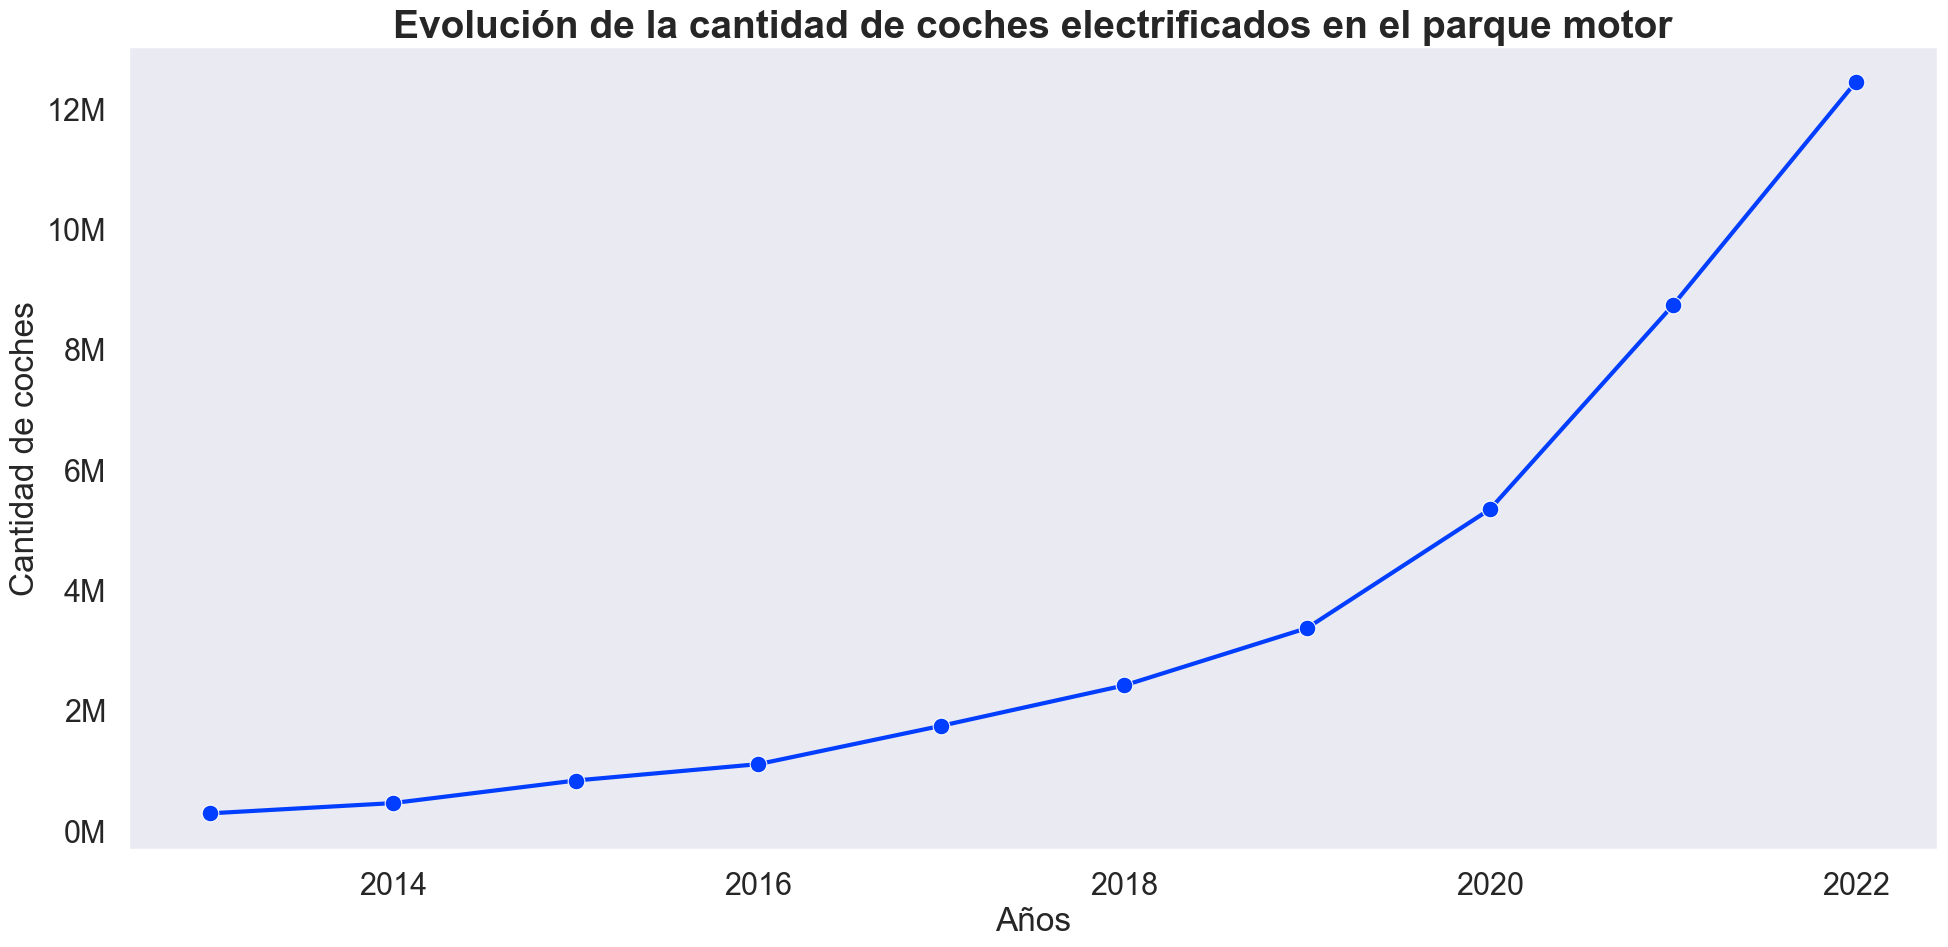

In [38]:
plt.figure(figsize=(20, 10), tight_layout=True)
ax = sns.lineplot(
    data=df_cars_park.melt(
        id_vars='Años',
        value_vars='Electrificados',
        var_name='Motor',
        value_name='Cantidad de coches'),
    x='Años',
    y='Cantidad de coches',
    color='#023eff',
    marker='o')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))
plt.title(
    'Evolución de la cantidad de coches electrificados en el parque motor',
    fontdict={'fontsize':28, 'fontweight':'bold'})
plt.show()

El gráfico muestra cómo los coches _electrificados_ han pasado de ser un segmento marginal del parque automotor europeo a consolidarse como una parte significativa en menos de una década.

El número de coches _electrificados_ ha experimentado un crecimiento exponencial desde 2013, pasando de menos de un millón a superar los 12 millones en 2022. Entre 2013 y 2017 el crecimiento fue moderado, pero a partir de 2018 se observa una clara aceleración, con incrementos anuales cada vez más pronunciados.

En conjunto, el gráfico ilustra una transformación estructural del parque automotor, lo que refleja la aceleración en la adopción de esta tecnología.

#### __¿Cómo se relaciona el aumento de los coches electrificados con las emisiones de GEI procedentes del uso de automóviles en Europa?__

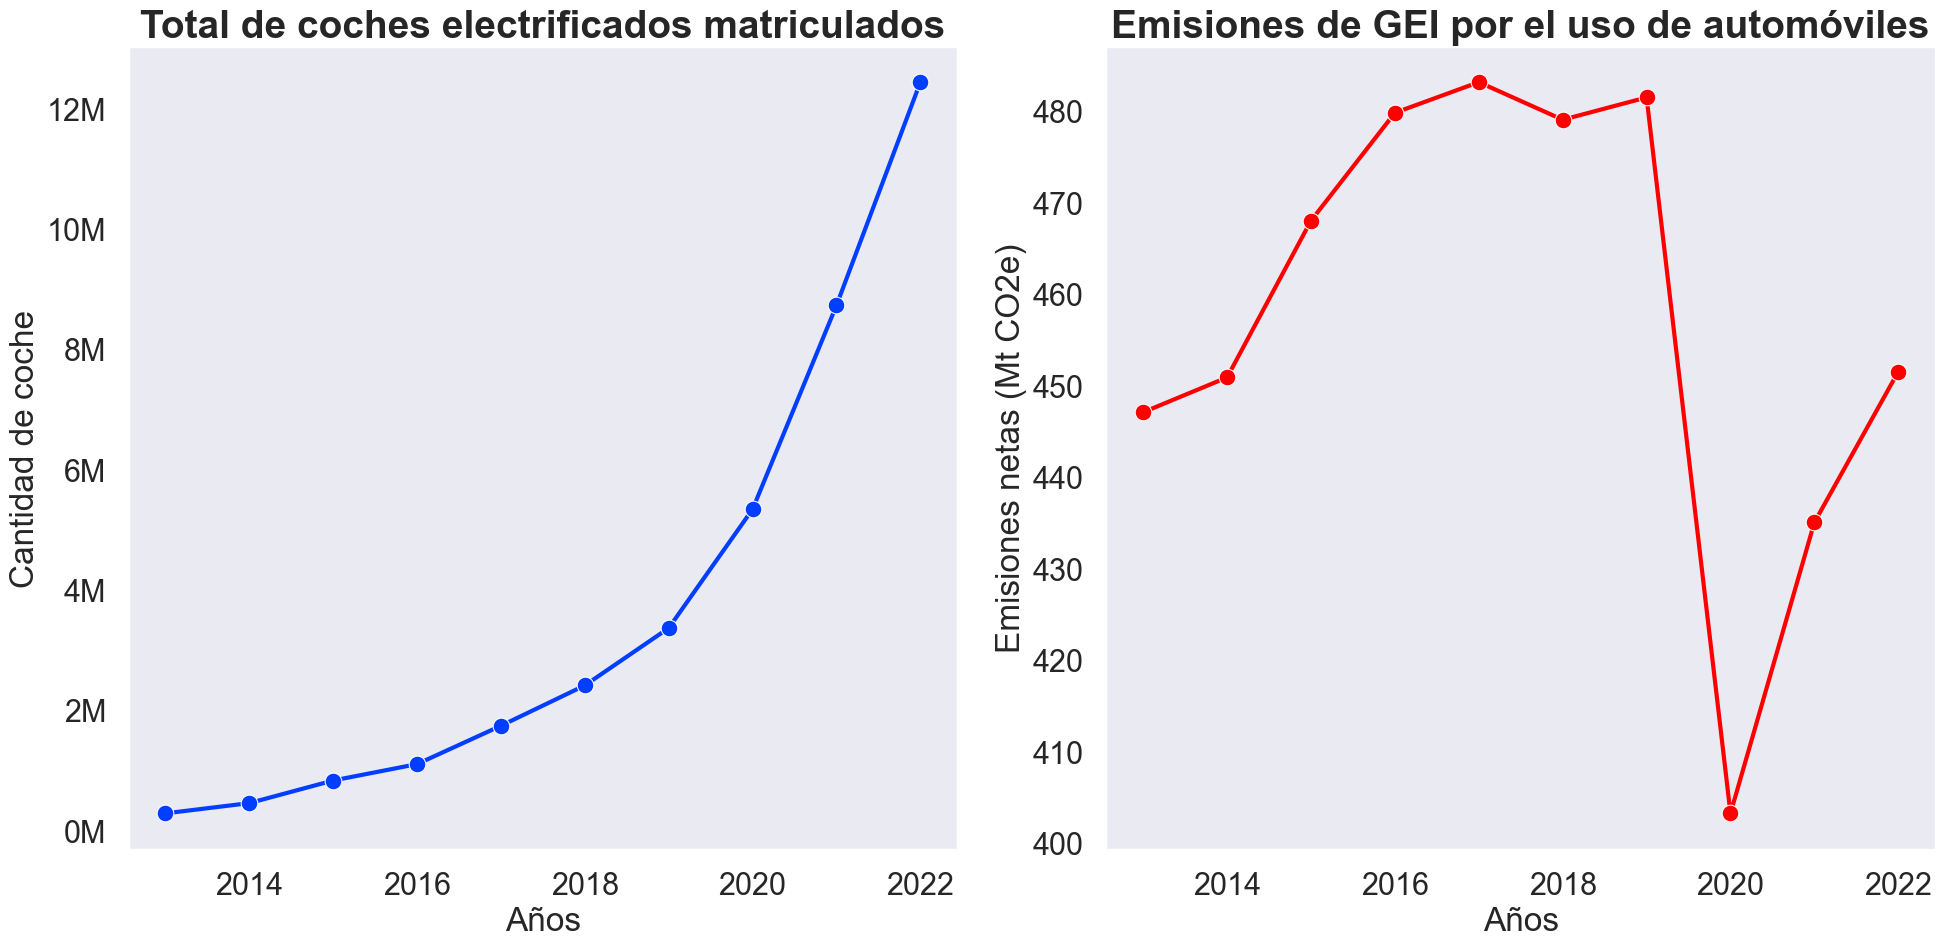

In [45]:
df_cars_ghg_x_evo_elec = df_greenhouse_gases.merge(df_cars_park, how='inner', on='Años').reset_index(drop=True)

fig, (axes1, axes2) = plt.subplots(1, 2, figsize=(20, 10), tight_layout=True)
# Gráfico 1: Evolución de vehículos electrificados
axes1 = sns.lineplot(
    data=df_cars_ghg_x_evo_elec,
    x='Años',
    y='Electrificados',
    ax=axes1,
    color='#023eff',
    marker='o')
axes1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))
axes1.set_title(
    'Total de coches electrificados matriculados',
    fontdict={'fontsize':28, 'fontweight':'bold'})
axes1.set_ylabel('Cantidad de coche')

# Gráfico 2: Evolución de automóviles de combustión
axes2 = sns.lineplot(
    data=df_cars_ghg_x_evo_elec,
    x='Años',
    y='Combustión_en_automóviles',
    ax=axes2,
    color='red',
    marker='o')
#axes2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e0:.0f}K'))
axes2.set_title(
    'Emisiones de GEI por el uso de automóviles',
    fontdict={'fontsize':28, 'fontweight':'bold'})
axes2.set_ylabel('Emisiones netas (Mt CO2e)')
plt.show()

El gráfico muestra una comparativa entre el total acumulado de los coches _electrificados_ en el parque automotor por año (izquierda) y las emisiones de gases de efecto invernadero derivadas del uso de automóviles (derecha).

Desde 2013 hasta 2019, las emisiones de GEI se mantuvieron relativamente altas, a pesar del crecimiento moderado de los coches _electrificados_ en el parque automotriz. Sin embargo, a partir de 2020, se observa una ruptura en la tendencia: mientras la cantidad de coches _electrificados_ se dispara de forma exponencial, las emisiones caen drásticamente, en parte también por la menor movilidad durante la pandemia.

Aunque las emisiones repuntan ligeramente en 2021-2022, no alcanzan los niveles previos a 2019, lo que sugiere que la electrificación del parque automotor está empezando a tener un impacto tangible en la reducción de emisiones.

En síntesis, el gráfico evidencia una correlación inversa: a medida que aumenta la adopción de vehículos _electrificados_, las emisiones del sector transporte comienzan a descender, marcando un paso importante hacia la descarbonización del transporte en Europa.

#### __¿Cómo ha evolucionado el total de coches electrificados matriculados frente a la proporción anual de coches de combustión interna en Europa?__

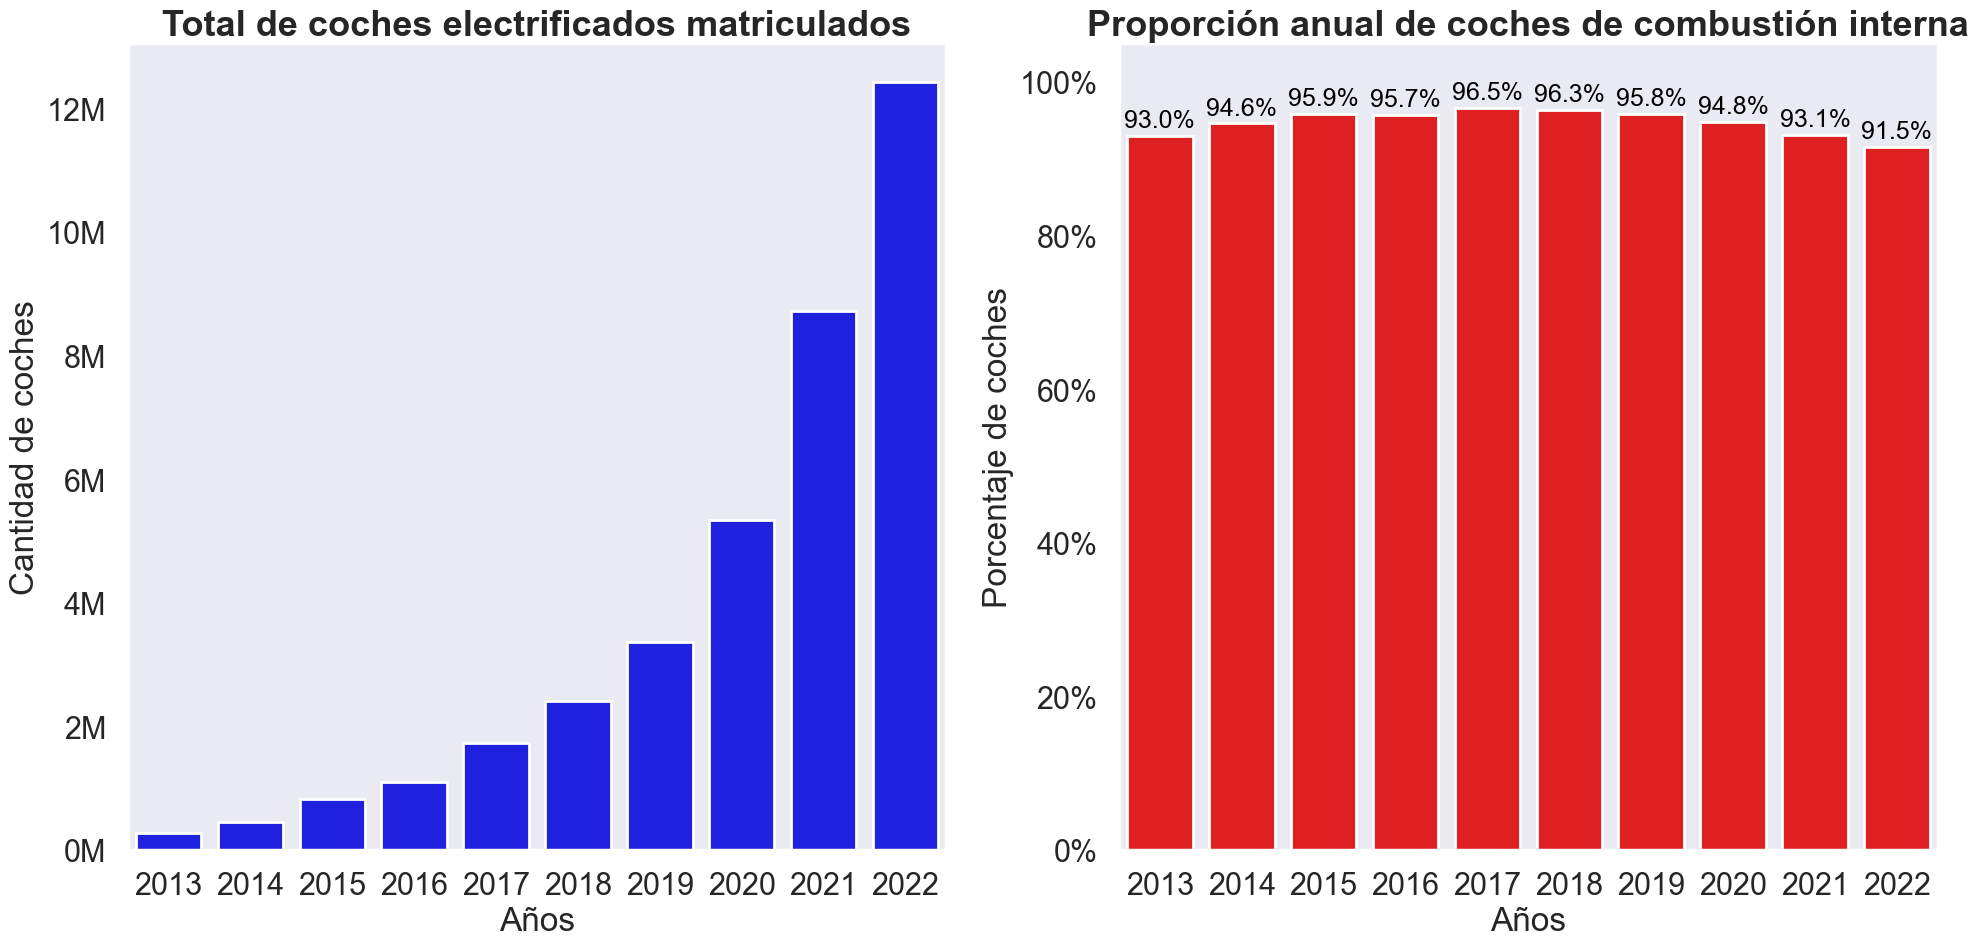

In [40]:
df_cars_park_pct = df_cars_park

df_cars_park_pct['Porcentaje_Combustión'] = (
    ((df_cars_park_pct[['Gasolina', 'Diesel']].sum(axis=1)) / df_cars_park_pct['Total'])
    * 100 ).round(2)

fig, (axes1, axes2) = plt.subplots(1, 2, figsize=(20, 10), tight_layout=True)
# Gráfico 1: Coches electrificados por año
axes1 = sns.barplot(
    data=df_cars_park_pct,
    x='Años',
    y='Electrificados',
    color='blue', ax=axes1)
axes1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))
axes1.set_title(
    'Total de coches electrificados matriculados',
    fontdict={'fontsize':26, 'fontweight':'bold'})
axes1.set_ylabel('Cantidad de coches')

# Gráfico 2: Proporción de coches de combustión interna por año
axes2 = sns.barplot(
    data=df_cars_park_pct,
    x='Años',
    y='Porcentaje_Combustión',
    color='red', ax=axes2)
axes2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e0:.0f}%'))
axes2.set_title(
    'Proporción anual de coches de combustión interna',
    fontdict={'fontsize':26, 'fontweight':'bold'})
axes2.set_ylabel('Porcentaje de coches')
axes2.set_ylim(0, 105)
# Porcentajes sobre las barras
for p in axes2.patches:
    height = p.get_height()
    axes2.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center', va='bottom',
        fontsize=18, color='black')
plt.show()

El gráfico compara dos tendencias complementarias: por un lado, el aumento acumulado de coches _electrificados_ matriculados por año (izquierda), y por otro, la proporción anual de coches de _combustión interna_ sobre el total (derecha).

Desde 2013 hasta 2022, se observa una expansión sostenida y acelerada de los vehículos _electrificados_, con un crecimiento es especialmente pronunciado a partir de 2020.

En contraste, la proporción de coches de _combustión interna_, aunque todavía supera el 90 % del total, muestra una tendencia descendente. Entre 2013 y 2022, su participación cae alrededor de 1,5 puntos porcentuales y en 5 puntos porcentuales entre 2017 y 2022, siendo 2017 el punto donde la proporción de coches de _combustión interna_ fue la más grande, reflejando el inicio de una transición estructural en el mercado automotriz.

En conjunto, ambos indicadores revelan que Europa está avanzando hacia la electrificación del transporte, pero aún se encuentra en una fase de coexistencia entre tecnologías: la flota eléctrica crece rápidamente, pero el parque de combustión continúa representando la mayor parte del total de vehículos matriculados.

___
___